### Introduction

The code consists of training and test process on epochs 10 with combination of learning rates {1e-3, 1e-4, 1e-5} and batch size {32, 64}. The results of two-stage architecture are based on respective best three models under 10 epochs. The final two-stage architecture results please refer to the 'Evaluation' code. 


In [ ]:
### EXP 1：one stage classifier 10 epochs

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet50_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
base_path = '/content/MA'
output_dir = base_path

# Class Mapping
classes = {
    "ALS": 0,
    "Covid-19": 1,
    "Dysphonie": 2,
    "HC": 3,
    "Laryngitis": 4,
    "Parkinson": 5,
    "Rekurrensparese": 6
}

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32)
        if mel.ndim == 2:
            mel = mel.unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=7):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

train_set_path = os.path.join(base_path, "/content/MA/train_set.xlsx")
test_set_path = os.path.join(base_path, "/content/MA/test_set.xlsx")
train_df = pd.read_excel(train_set_path)
test_df = pd.read_excel(test_set_path)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        pathology = row['Pathology']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and pathology in classes:
            files.append(full_path)
            labels.append(classes[pathology])
        else:
            print(f"Warning: File {full_path} does not exist or invalid pathology.")
    return files, labels

train_files, train_labels = get_file_paths_and_labels(train_df, base_path)
test_files, test_labels = get_file_paths_and_labels(test_df, base_path)

test_dataset = MelDataset(test_files, test_labels)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Loss curve (optional)
def plot_loss(train_losses, val_losses, fold):
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Train vs Validation Loss - Fold {fold}")
    plt.legend()
    plt.savefig(os.path.join(output_dir, f"loss_curve_fold_{fold}.png"))
    plt.close()

# Validation MCC
def save_metrics(metrics, fold):
    metrics_df = pd.DataFrame(metrics, columns=["Epoch", "MCC"])
    metrics_df.to_csv(os.path.join(output_dir, f"validation_metrics_fold_{fold}.csv"), index=False)

# Test Set Evaluation
def evaluate_on_test_set(model, test_loader, fold):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

    # Confusion Matrix
    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Test Set (Fold {fold})")
    plt.savefig(os.path.join(output_dir, f"test_confusion_matrix_fold_{fold}.png"))
    plt.close()

    mcc = matthews_corrcoef(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"Test Set Results - Fold {fold}: MCC: {mcc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

    # Test Set index
    test_results_path = os.path.join(output_dir, "test_metrics.csv")
    if not os.path.exists(test_results_path):
        with open(test_results_path, "w") as f:
            f.write("Fold,MCC,Precision,Recall,F1\n")
    with open(test_results_path, "a") as f:
        f.write(f"{fold},{mcc:.4f},{precision:.4f},{recall:.4f},{f1:.4f}\n")

cv_results = []

best_params = None
best_model = None
best_val_mcc = -float('inf')

for batch_size, lr in itertools.product([32, 64], [1e-3, 1e-4, 1e-5]):
    print(f"Testing parameter combination: batch_size={batch_size}, lr={lr}")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
    fold = 1
    fold_metrics = []

    for train_idx, val_idx in skf.split(train_files, train_labels):
        print(f"Starting Fold {fold} with batch_size={batch_size}, lr={lr}")

        train_dataset = MelDataset([train_files[i] for i in train_idx], [train_labels[i] for i in train_idx])
        val_dataset = MelDataset([train_files[i] for i in val_idx], [train_labels[i] for i in val_idx])
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model = ResNet50Classifier(num_classes=len(classes)).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        train_losses, val_losses = [], []

        for epoch in range(10):
            model.train()
            total_train_loss = 0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item()

            model.eval()
            total_val_loss = 0
            y_true, y_pred = [], []
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    total_val_loss += loss.item()
                    y_true.extend(labels.cpu().numpy())
                    y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

            train_loss = total_train_loss / len(train_loader)
            val_loss = total_val_loss / len(val_loader)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

        mcc = matthews_corrcoef(y_true, y_pred)
        fold_metrics.append(mcc)
        print(f"Fold {fold} | MCC: {mcc:.4f}")
        fold += 1

    avg_mcc = np.mean(fold_metrics)
    std_mcc = np.std(fold_metrics)
    print(f"Cross-Validation Results for batch_size={batch_size}, lr={lr}: Avg MCC={avg_mcc:.4f}, Std MCC={std_mcc:.4f}")
    cv_results.append((batch_size, lr, avg_mcc, std_mcc))

    if avg_mcc > best_val_mcc:
        best_val_mcc = avg_mcc
        best_params = (batch_size, lr)
        best_model = model

cv_results_df = pd.DataFrame(cv_results, columns=["Batch Size", "Learning Rate", "Avg MCC", "Std MCC"])
cv_results_df.to_csv(os.path.join(output_dir, "cv_results.csv"), index=False)
print(cv_results_df)


print(f"Best Parameters Found: Batch Size={best_params[0]}, Learning Rate={best_params[1]}, Avg MCC={best_val_mcc:.4f}")
# Retrain on whole training set
print("Retraining model with best parameters on full training set...")
final_train_dataset = MelDataset(train_files, train_labels)
final_train_loader = DataLoader(final_train_dataset, batch_size=best_params[0], shuffle=True)
final_model = ResNet50Classifier(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params[1])

for epoch in range(10):
    final_model.train()
    total_train_loss = 0
    for inputs, labels in final_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = final_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(final_train_loader)
    print(f"Retrain Epoch {epoch + 1}: Train Loss: {avg_train_loss:.4f}")

torch.save(final_model.state_dict(), os.path.join(output_dir, "final_model.pth"))
print("Final trained model saved successfully.")

print("Evaluating final model on test set...")
evaluate_on_test_set(final_model, test_loader, "Final")


Using device: cuda
Testing parameter combination: batch_size=32, lr=0.001
Starting Fold 1 with batch_size=32, lr=0.001


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 167MB/s]


Epoch 1: Train Loss: 0.7742, Validation Loss: 0.7963
Epoch 2: Train Loss: 0.5995, Validation Loss: 0.6024
Epoch 3: Train Loss: 0.5826, Validation Loss: 0.7975
Epoch 4: Train Loss: 0.5021, Validation Loss: 0.5057
Epoch 5: Train Loss: 0.4437, Validation Loss: 0.5331
Epoch 6: Train Loss: 0.3893, Validation Loss: 0.4300
Epoch 7: Train Loss: 0.3586, Validation Loss: 0.3889
Epoch 8: Train Loss: 0.3132, Validation Loss: 0.3900
Epoch 9: Train Loss: 0.2825, Validation Loss: 0.3736
Epoch 10: Train Loss: 0.2420, Validation Loss: 0.3929
Fold 1 | MCC: 0.7101
Starting Fold 2 with batch_size=32, lr=0.001
Epoch 1: Train Loss: 0.7720, Validation Loss: 0.7333
Epoch 2: Train Loss: 0.6022, Validation Loss: 2.8161
Epoch 3: Train Loss: 0.5478, Validation Loss: 0.7276
Epoch 4: Train Loss: 0.4693, Validation Loss: 0.4929
Epoch 5: Train Loss: 0.4269, Validation Loss: 0.4696
Epoch 6: Train Loss: 0.3876, Validation Loss: 0.4044
Epoch 7: Train Loss: 0.3457, Validation Loss: 0.4406
Epoch 8: Train Loss: 0.3052, Val

In [ ]:
### EXP 2: two stage architecture classifier

In [ ]:
### classifier PD training

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet50_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

base_path = '/content/MA'
output_dir = base_path

# Class Mapping
classes = {
    "MC": 0,  # Male Control
    "MP": 1,  # Male Pathology
    "FC": 2,  # Female Control
    "FP": 3   # Female Pathology
}

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32)
        if mel.ndim == 2:
            mel = mel.unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

#  Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=4):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        group = row['Group']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and group in classes:
            files.append(full_path)
            labels.append(classes[group])
        else:
            print(f"Warning: File {full_path} does not exist or invalid group.")
    return files, labels

train_set_path = os.path.join(base_path, "train_set.xlsx")
test_set_path = os.path.join(base_path, "test_set.xlsx")
train_df = pd.read_excel(train_set_path)
test_df = pd.read_excel(test_set_path)

train_files, train_labels = get_file_paths_and_labels(train_df, base_path)
test_files, test_labels = get_file_paths_and_labels(test_df, base_path)

test_dataset = MelDataset(test_files, test_labels)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

def plot_loss(train_losses, val_losses, fold):
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Train vs Validation Loss - Fold {fold}")
    plt.legend()
    plt.savefig(os.path.join(output_dir, f"loss_curve_fold_{fold}.png"))
    plt.close()

def save_metrics(metrics, fold):
    metrics_df = pd.DataFrame(metrics, columns=["Epoch", "MCC"])
    metrics_df.to_csv(os.path.join(output_dir, f"validation_metrics_fold_{fold}.csv"), index=False)

def save_test_metrics(fold, mcc):
    test_results_path = os.path.join(output_dir, "test_metrics.csv")
    if not os.path.exists(test_results_path):
        with open(test_results_path, "w") as f:
            f.write("Fold,MCC\n")
    with open(test_results_path, "a") as f:
        f.write(f"{fold},{mcc:.4f}\n")

def evaluate_on_test_set(model, test_loader, fold):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Test Set (Fold {fold})")
    plt.savefig(os.path.join(output_dir, f"test_confusion_matrix_fold_{fold}.png"))
    plt.close()

    mcc = matthews_corrcoef(y_true, y_pred)
    print(f"Test Set Results - Fold {fold}: MCC: {mcc:.4f}")
    save_test_metrics(fold, mcc)

batch_sizes = [32, 64]
learning_rates = [1e-3, 1e-4, 1e-5]
param_combinations = list(itertools.product(batch_sizes, learning_rates))

best_params = None
best_model = None
best_val_mcc = -1

cv_results = []

for batch_size, lr in param_combinations:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
    fold = 1

    last_mcc_values = []

    for train_idx, val_idx in skf.split(train_files, train_labels):
        print(f"Starting Fold {fold} with batch_size={batch_size}, lr={lr}")

        train_dataset = MelDataset([train_files[i] for i in train_idx], [train_labels[i] for i in train_idx])
        val_dataset = MelDataset([train_files[i] for i in val_idx], [train_labels[i] for i in val_idx])
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model = ResNet50Classifier(num_classes=len(classes)).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        train_losses, val_losses = [], []

        for epoch in range(10):
            model.train()
            total_train_loss = 0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item()

            model.eval()
            total_val_loss = 0
            y_true, y_pred = [], []
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    total_val_loss += loss.item()
                    y_true.extend(labels.cpu().numpy())
                    y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

            train_loss = total_train_loss / len(train_loader)
            val_loss = total_val_loss / len(val_loader)
            train_losses.append(train_loss)
            val_losses.append(val_loss)

            print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

        last_mcc = matthews_corrcoef(y_true, y_pred)
        last_mcc_values.append(last_mcc)
        print(f"Fold {fold} | MCC: {last_mcc:.4f}")
        fold += 1

    avg_mcc = np.mean(last_mcc_values)
    print(f"Average MCC for batch_size={batch_size}, lr={lr}: {avg_mcc:.4f}")

    if avg_mcc > best_val_mcc:
        best_val_mcc = avg_mcc
        best_params = (batch_size, lr)
        best_model = model

print(f"Best Parameters: batch_size={best_params[0]}, lr={best_params[1]} with MCC={best_val_mcc:.4f}")

# Retrain on whole test set
final_train_dataset = MelDataset(train_files, train_labels)
final_train_loader = DataLoader(final_train_dataset, batch_size=best_params[0], shuffle=True)
final_model = ResNet50Classifier(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params[1])

train_losses = []

for epoch in range(10):
    final_model.train()
    total_train_loss = 0
    for inputs, labels in final_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = final_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(final_train_loader)
    train_losses.append(avg_train_loss)
    print(f"Retrain Epoch {epoch + 1}: Train Loss: {avg_train_loss:.4f}")

final_model_save_path = os.path.join(output_dir, "final_group_classifier.pth")
torch.save(final_model.state_dict(), final_model_save_path)
print(f"Final model saved to {final_model_save_path}")

final_model.load_state_dict(torch.load(final_model_save_path))
evaluate_on_test_set(final_model, test_loader, "Final")


Using device: cuda
Starting Fold 1 with batch_size=32, lr=0.001


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 181MB/s]


Epoch 1: Train Loss: 0.7511, Validation Loss: 0.7173
Epoch 2: Train Loss: 0.5850, Validation Loss: 0.5734
Epoch 3: Train Loss: 0.5266, Validation Loss: 0.6130
Epoch 4: Train Loss: 0.4288, Validation Loss: 0.4860
Epoch 5: Train Loss: 0.3485, Validation Loss: 0.4321
Epoch 6: Train Loss: 0.2896, Validation Loss: 0.3902
Epoch 7: Train Loss: 0.2394, Validation Loss: 0.3179
Epoch 8: Train Loss: 0.2129, Validation Loss: 0.3410
Epoch 9: Train Loss: 0.1650, Validation Loss: 0.3466
Epoch 10: Train Loss: 0.1778, Validation Loss: 0.2661
Fold 1 | MCC: 0.8636
Starting Fold 2 with batch_size=32, lr=0.001
Epoch 1: Train Loss: 0.7660, Validation Loss: 0.7736
Epoch 2: Train Loss: 0.6205, Validation Loss: 0.7774
Epoch 3: Train Loss: 0.5059, Validation Loss: 0.5716
Epoch 4: Train Loss: 0.4403, Validation Loss: 0.5261
Epoch 5: Train Loss: 0.4016, Validation Loss: 0.5601
Epoch 6: Train Loss: 0.3304, Validation Loss: 0.3963
Epoch 7: Train Loss: 0.2778, Validation Loss: 0.3154
Epoch 8: Train Loss: 0.2444, Val

<ipython-input-2-29c3fe41e40e>:257: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load(final_model_save_path))


Test Set Results - Fold Final: MCC: 0.9292


In [ ]:
## classifier PD test

<ipython-input-3-99cc715392d4>:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load('/content/MA/final_group_classifier.pth'))


Precision: 0.9523
Recall: 0.9511
F1 Score: 0.9512
MCC: 0.9292


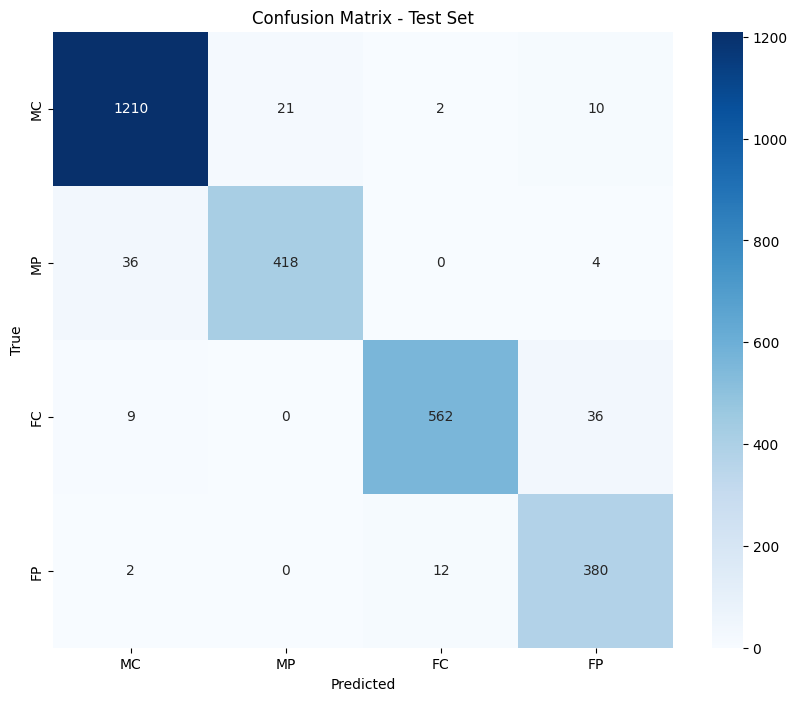

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model_on_test_set(model, test_loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            predictions = torch.argmax(outputs, axis=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix - Test Set")
    plt.show()

    return precision, recall, f1, mcc

final_model.load_state_dict(torch.load('/content/MA/final_group_classifier.pth'))
final_model.to(device)

precision, recall, f1, mcc = evaluate_model_on_test_set(final_model, test_loader)


In [ ]:
### classifier MP training

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet50_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

base_path = '/content/MA'
output_dir = base_path

# Class Mapping
classes = {
    "ALS": 0,
    "Covid-19": 1,
    "Dysphonie": 2,
    "Laryngitis": 3,
    "Parkinson": 4,
    "Rekurrensparese": 5
}

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32)
        if mel.ndim == 2:
            mel = mel.unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=7):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

train_set_path = os.path.join(base_path, "train_set.xlsx")
test_set_path = os.path.join(base_path, "test_set.xlsx")
train_df = pd.read_excel(train_set_path)
test_df = pd.read_excel(test_set_path)

def filter_mp_group(df):
    filtered_df = df[(df['Group'] == 'MP') & (df['Pathology'] != 'HC')]
    if filtered_df.empty:
        raise ValueError("No valid samples found after filtering for Group=MP and excluding HC.")
    return filtered_df

filtered_train_df = filter_mp_group(train_df)
filtered_test_df = filter_mp_group(test_df)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        pathology = row['Pathology']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and pathology in classes:
            files.append(full_path)
            labels.append(classes[pathology])
        else:
            print(f"Warning: File {full_path} does not exist or invalid pathology.")
    return files, labels

train_files, train_labels = get_file_paths_and_labels(filtered_train_df, base_path)
test_files, test_labels = get_file_paths_and_labels(filtered_test_df, base_path)

print(f"Filtered training samples: {len(train_files)}")
print(f"Filtered testing samples: {len(test_files)}")

test_dataset = MelDataset(test_files, test_labels)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

def plot_loss(train_losses, val_losses, fold):
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Train vs Validation Loss - Fold {fold}")
    plt.legend()
    plt.savefig(os.path.join(output_dir, f"loss_curve_fold_{fold}.png"))
    plt.close()

def save_metrics(metrics, fold):
    metrics_df = pd.DataFrame(metrics, columns=["Epoch", "MCC"])
    metrics_df.to_csv(os.path.join(output_dir, f"validation_metrics_fold_{fold}.csv"), index=False)

def save_test_metrics(fold, mcc):
    test_results_path = os.path.join(output_dir, "test_metrics_MP.csv")
    if not os.path.exists(test_results_path):
        with open(test_results_path, "w") as f:
            f.write("Fold,MCC\n")
    with open(test_results_path, "a") as f:
        f.write(f"{fold},{mcc:.4f}\n")

def evaluate_on_test_set(model, test_loader, fold):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Test Set (Fold {fold})")
    plt.savefig(os.path.join(output_dir, f"test_confusion_MP_matrix_fold_{fold}.png"))
    plt.close()

    mcc = matthews_corrcoef(y_true, y_pred)
    print(f"Test Set Results - Fold {fold}: MCC: {mcc:.4f}")
    save_test_metrics(fold, mcc)

batch_sizes = [32, 64]
learning_rates = [1e-3, 1e-4, 1e-5]
param_combinations = list(itertools.product(batch_sizes, learning_rates))
print("Hyperparameter combinations:")
for combo in param_combinations:
    print(combo)

best_params = None
best_model = None
best_val_mcc = -1

cv_results = []

for batch_size, lr in param_combinations:
    print(f"Testing parameter combination: batch_size={batch_size}, lr={lr}")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
    fold = 1
    fold_metrics = []

    for train_idx, val_idx in skf.split(train_files, train_labels):
        print(f"Starting Fold {fold} with batch_size={batch_size}, lr={lr}")

        train_dataset = MelDataset([train_files[i] for i in train_idx], [train_labels[i] for i in train_idx])
        val_dataset = MelDataset([train_files[i] for i in val_idx], [train_labels[i] for i in val_idx])
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model = ResNet50Classifier(num_classes=len(classes)).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        train_losses, val_losses = [], []

        for epoch in range(10):
            model.train()
            total_train_loss = 0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item()

            model.eval()
            total_val_loss = 0
            y_true, y_pred = [], []
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    total_val_loss += loss.item()
                    y_true.extend(labels.cpu().numpy())
                    y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

            train_loss = total_train_loss / len(train_loader)
            val_loss = total_val_loss / len(val_loader)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

        mcc = matthews_corrcoef(y_true, y_pred)
        fold_metrics.append(mcc)
        print(f"Fold {fold} | MCC: {mcc:.4f}")
        fold += 1

    avg_mcc = sum(fold_metrics) / len(fold_metrics)
    cv_results.append((batch_size, lr, avg_mcc))

    if avg_mcc > best_val_mcc:
        best_val_mcc = avg_mcc
        best_params = (batch_size, lr)
        best_model = model

print(f"Best parameters: batch_size={best_params[0]}, lr={best_params[1]} with MCC={best_val_mcc:.4f}")

# Retrain based on whole test set
print("Retraining model with best parameters on full training set...")
final_train_dataset = MelDataset(train_files, train_labels)
final_train_loader = DataLoader(final_train_dataset, batch_size=best_params[0], shuffle=True)
final_model = ResNet50Classifier(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params[1])

for epoch in range(10):
    final_model.train()
    total_train_loss = 0
    for inputs, labels in final_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = final_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(final_train_loader)
    print(f"Retrain Epoch {epoch + 1}: Train Loss: {avg_train_loss:.4f}")

model_save_path = os.path.join(output_dir, "best_resnet50_MP_model.pth")
torch.save(final_model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

print("Evaluating final model on test set...")
evaluate_on_test_set(final_model, test_loader, "Final")


Using device: cuda
Filtered training samples: 1748
Filtered testing samples: 458
Hyperparameter combinations:
(32, 0.001)
(32, 0.0001)
(32, 1e-05)
(64, 0.001)
(64, 0.0001)
(64, 1e-05)
Testing parameter combination: batch_size=32, lr=0.001
Starting Fold 1 with batch_size=32, lr=0.001
Epoch 1: Train Loss: 0.6190, Validation Loss: 1.0154
Epoch 2: Train Loss: 0.3675, Validation Loss: 0.4010
Epoch 3: Train Loss: 0.3330, Validation Loss: 0.3903
Epoch 4: Train Loss: 0.3809, Validation Loss: 0.4140
Epoch 5: Train Loss: 0.2868, Validation Loss: 0.3138
Epoch 6: Train Loss: 0.2654, Validation Loss: 0.3767
Epoch 7: Train Loss: 0.2118, Validation Loss: 0.3345
Epoch 8: Train Loss: 0.2140, Validation Loss: 0.2537
Epoch 9: Train Loss: 0.2043, Validation Loss: 0.2907
Epoch 10: Train Loss: 0.1508, Validation Loss: 0.4128
Fold 1 | MCC: 0.8022
Starting Fold 2 with batch_size=32, lr=0.001
Epoch 1: Train Loss: 0.6124, Validation Loss: 0.4411
Epoch 2: Train Loss: 0.3765, Validation Loss: 0.7661
Epoch 3: Trai

In [ ]:
### classifier MP test

<ipython-input-5-5a625e53b0fb>:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load('/content/MA/best_resnet50_MP_model.pth'))


Precision: 0.9757
Recall: 0.9738
F1 Score: 0.9736
MCC: 0.9590


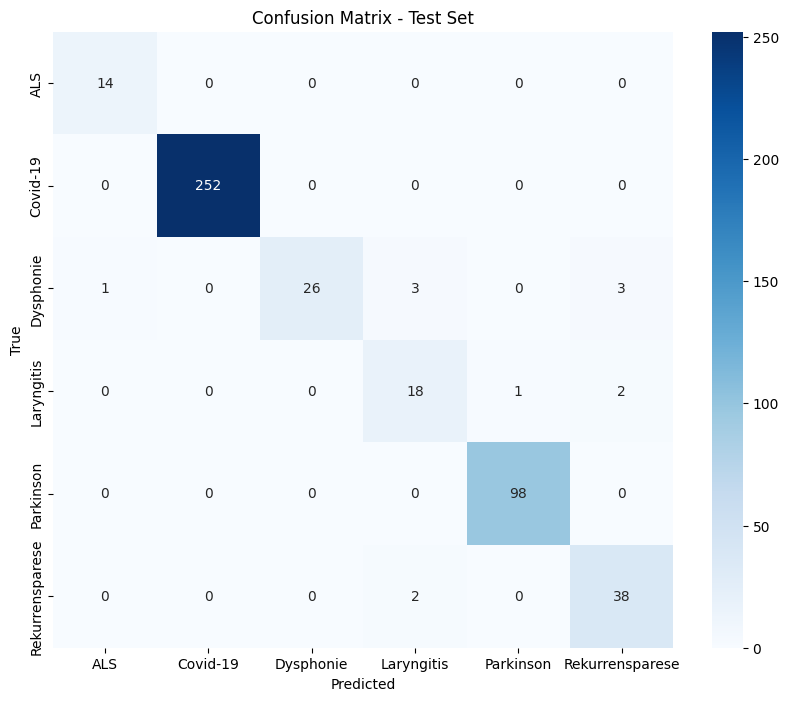

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model_on_test_set(model, test_loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            predictions = torch.argmax(outputs, axis=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix - Test Set")
    plt.show()

    return precision, recall, f1, mcc

final_model.load_state_dict(torch.load('/content/MA/best_resnet50_MP_model.pth'))
final_model.to(device)

precision, recall, f1, mcc = evaluate_model_on_test_set(final_model, test_loader)

In [ ]:
## classifier FP training

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet50_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

base_path = '/content/MA'
output_dir = base_path

# Class Mapping
classes = {
    "ALS": 0,
    "Covid-19": 1,
    "Dysphonie": 2,
    "Laryngitis": 3,
    "Parkinson": 4,
    "Rekurrensparese": 5
}

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32)
        if mel.ndim == 2:
            mel = mel.unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=7):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

train_set_path = os.path.join(base_path, "train_set.xlsx")
test_set_path = os.path.join(base_path, "test_set.xlsx")
train_df = pd.read_excel(train_set_path)
test_df = pd.read_excel(test_set_path)

def filter_mp_group(df):
    filtered_df = df[(df['Group'] == 'FP') & (df['Pathology'] != 'HC')]
    if filtered_df.empty:
        raise ValueError("No valid samples found after filtering for Group=FP and excluding HC.")
    return filtered_df

filtered_train_df = filter_mp_group(train_df)
filtered_test_df = filter_mp_group(test_df)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        pathology = row['Pathology']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and pathology in classes:
            files.append(full_path)
            labels.append(classes[pathology])
        else:
            print(f"Warning: File {full_path} does not exist or invalid pathology.")
    return files, labels

train_files, train_labels = get_file_paths_and_labels(filtered_train_df, base_path)
test_files, test_labels = get_file_paths_and_labels(filtered_test_df, base_path)

print(f"Filtered training samples: {len(train_files)}")
print(f"Filtered testing samples: {len(test_files)}")

test_dataset = MelDataset(test_files, test_labels)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

def plot_loss(train_losses, val_losses, fold):
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Train vs Validation Loss - Fold {fold}")
    plt.legend()
    plt.savefig(os.path.join(output_dir, f"loss_curve_fold_{fold}.png"))
    plt.close()

def save_metrics(metrics, fold):
    metrics_df = pd.DataFrame(metrics, columns=["Epoch", "MCC"])
    metrics_df.to_csv(os.path.join(output_dir, f"validation_metrics_fold_{fold}.csv"), index=False)

def save_test_metrics(fold, mcc):
    test_results_path = os.path.join(output_dir, "test_metrics_FP.csv")
    if not os.path.exists(test_results_path):
        with open(test_results_path, "w") as f:
            f.write("Fold,MCC\n")
    with open(test_results_path, "a") as f:
        f.write(f"{fold},{mcc:.4f}\n")

def evaluate_on_test_set(model, test_loader, fold):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Test Set (Fold {fold})")
    plt.savefig(os.path.join(output_dir, f"test_confusion_FP_matrix_fold_{fold}.png"))
    plt.close()

    mcc = matthews_corrcoef(y_true, y_pred)
    print(f"Test Set Results - Fold {fold}: MCC: {mcc:.4f}")
    save_test_metrics(fold, mcc)

batch_sizes = [32, 64]
learning_rates = [1e-3, 1e-4, 1e-5]
param_combinations = list(itertools.product(batch_sizes, learning_rates))
print("Hyperparameter combinations:")
for combo in param_combinations:
    print(combo)

best_params = None
best_model = None
best_val_mcc = -1

cv_results = []

for batch_size, lr in param_combinations:
    print(f"Testing parameter combination: batch_size={batch_size}, lr={lr}")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
    fold = 1
    fold_metrics = []

    for train_idx, val_idx in skf.split(train_files, train_labels):
        print(f"Starting Fold {fold} with batch_size={batch_size}, lr={lr}")

        train_dataset = MelDataset([train_files[i] for i in train_idx], [train_labels[i] for i in train_idx])
        val_dataset = MelDataset([train_files[i] for i in val_idx], [train_labels[i] for i in val_idx])
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model = ResNet50Classifier(num_classes=len(classes)).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        train_losses, val_losses = [], []

        for epoch in range(10):
            model.train()
            total_train_loss = 0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item()

            model.eval()
            total_val_loss = 0
            y_true, y_pred = [], []
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    total_val_loss += loss.item()
                    y_true.extend(labels.cpu().numpy())
                    y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

            train_loss = total_train_loss / len(train_loader)
            val_loss = total_val_loss / len(val_loader)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

        mcc = matthews_corrcoef(y_true, y_pred)
        fold_metrics.append(mcc)
        print(f"Fold {fold} | MCC: {mcc:.4f}")
        fold += 1

    avg_mcc = sum(fold_metrics) / len(fold_metrics)
    cv_results.append((batch_size, lr, avg_mcc))

    if avg_mcc > best_val_mcc:
        best_val_mcc = avg_mcc
        best_params = (batch_size, lr)
        best_model = model

print(f"Best parameters: batch_size={best_params[0]}, lr={best_params[1]} with MCC={best_val_mcc:.4f}")

# Retrain on whole training set
print("Retraining model with best parameters on full training set...")
final_train_dataset = MelDataset(train_files, train_labels)
final_train_loader = DataLoader(final_train_dataset, batch_size=best_params[0], shuffle=True)
final_model = ResNet50Classifier(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params[1])

for epoch in range(10):
    final_model.train()
    total_train_loss = 0
    for inputs, labels in final_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = final_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(final_train_loader)
    print(f"Retrain Epoch {epoch + 1}: Train Loss: {avg_train_loss:.4f}")

model_save_path = os.path.join(output_dir, "best_resnet50_FP_model.pth")
torch.save(final_model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

print("Evaluating final model on test set...")
evaluate_on_test_set(final_model, test_loader, "Final")


Using device: cuda
Filtered training samples: 1659
Filtered testing samples: 394
Hyperparameter combinations:
(32, 0.001)
(32, 0.0001)
(32, 1e-05)
(64, 0.001)
(64, 0.0001)
(64, 1e-05)
Testing parameter combination: batch_size=32, lr=0.001
Starting Fold 1 with batch_size=32, lr=0.001
Epoch 1: Train Loss: 0.6344, Validation Loss: 0.6319
Epoch 2: Train Loss: 0.4217, Validation Loss: 0.4554
Epoch 3: Train Loss: 0.3655, Validation Loss: 0.3655
Epoch 4: Train Loss: 0.3191, Validation Loss: 0.3754
Epoch 5: Train Loss: 0.2806, Validation Loss: 0.7767
Epoch 6: Train Loss: 0.3844, Validation Loss: 0.3815
Epoch 7: Train Loss: 0.2864, Validation Loss: 0.6022
Epoch 8: Train Loss: 0.2022, Validation Loss: 0.4275
Epoch 9: Train Loss: 0.2173, Validation Loss: 0.2813
Epoch 10: Train Loss: 0.1461, Validation Loss: 0.4017
Fold 1 | MCC: 0.8175
Starting Fold 2 with batch_size=32, lr=0.001
Epoch 1: Train Loss: 0.6699, Validation Loss: 0.4339
Epoch 2: Train Loss: 0.3856, Validation Loss: 0.4580
Epoch 3: Trai

In [ ]:
### classifier FP test

<ipython-input-7-193dd2f226d0>:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load('/content/MA/best_resnet50_FP_model.pth'))


Precision: 0.9604
Recall: 0.9569
F1 Score: 0.9554
MCC: 0.9433


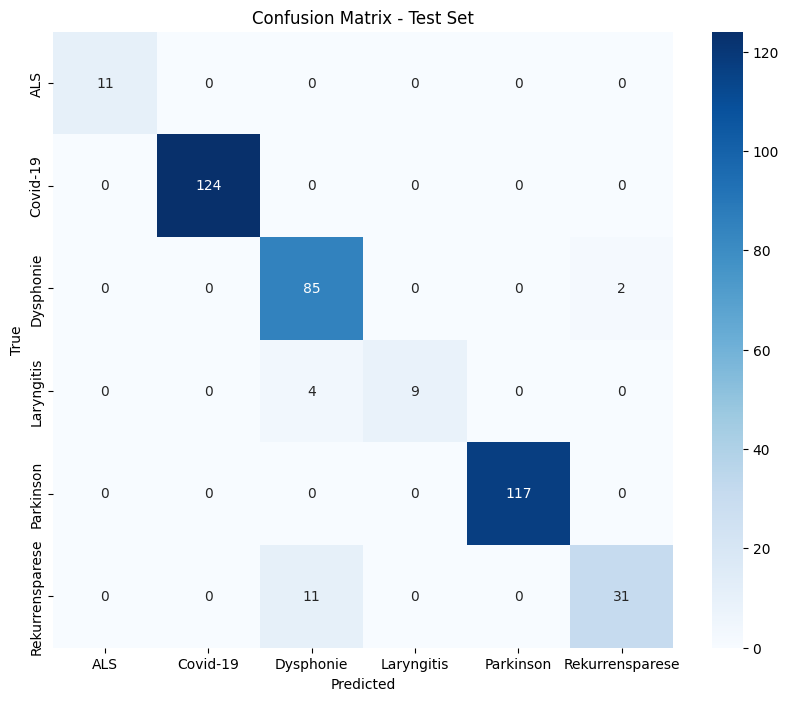

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model_on_test_set(model, test_loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            predictions = torch.argmax(outputs, axis=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix - Test Set")
    plt.show()

    return precision, recall, f1, mcc

final_model.load_state_dict(torch.load('/content/MA/best_resnet50_FP_model.pth'))
final_model.to(device)

precision, recall, f1, mcc = evaluate_model_on_test_set(final_model, test_loader)

In [ ]:
### two stage architecture test

Using device: cuda


<ipython-input-8-967018e60adb>:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=device)  # 确保加载到目标设备


Total test files: 2702
Total test labels: 2702
Running evaluation on the complete test set.
Total samples sent to the model: 2702
Samples classified as MC or FC (labeled as HC): 1833
Overall Precision: 0.9494
Overall Recall: 0.9489
Overall F1 Score: 0.9490
Overall MCC: 0.8991


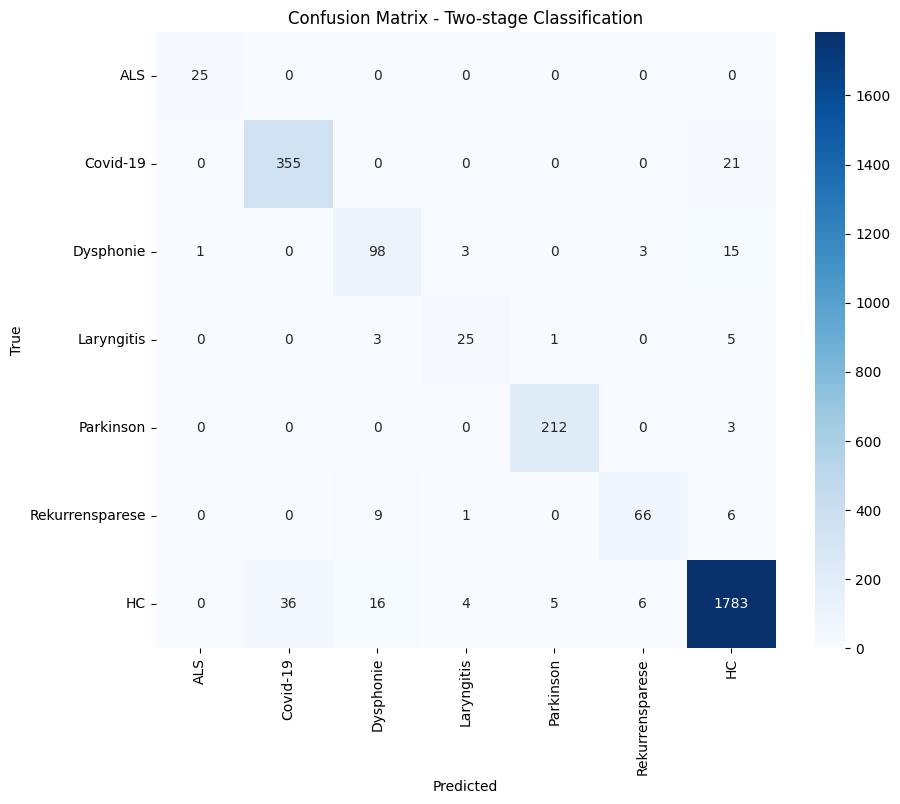

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import matthews_corrcoef, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Class Mapping
group_classes = {"MC": 0, "MP": 1, "FC": 2, "FP": 3}
disease_classes = {
    "ALS": 0,
    "Covid-19": 1,
    "Dysphonie": 2,
    "Laryngitis": 3,
    "Parkinson": 4,
    "Rekurrensparese": 5,
    "HC": 6
}

def load_model(model_path, num_classes):
    model = ResNet50Classifier(num_classes=num_classes)
    try:
        state_dict = torch.load(model_path, map_location=device)
        model.load_state_dict(state_dict)
    except Exception as e:
        print(f"Failed to load model weights from {model_path}: {e}")
        raise
    model.to(device)
    model.eval()
    return model

def get_test_loader(test_files, test_labels, batch_size=32):
    test_dataset = MelDataset(test_files, test_labels)
    return DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Load Group Classifier
group_model = load_model("/content/MA/final_group_classifier.pth", num_classes=4)

# Load MP and FP Classifier
mp_model = load_model("/content/MA/best_resnet50_MP_model.pth", num_classes=6)
fp_model = load_model("/content/MA/best_resnet50_FP_model.pth", num_classes=6)

test_set_path = os.path.join("/content/MA", "test_set.xlsx")
test_df = pd.read_excel(test_set_path)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        pathology = row['Pathology']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and pathology in disease_classes:
            files.append(full_path)
            labels.append(disease_classes[pathology])
        else:
            print(f"Warning: File {full_path} does not exist or invalid pathology.")
    return files, labels

test_files, test_labels = get_file_paths_and_labels(test_df, "/content/MA")

print(f"Total test files: {len(test_files)}")
print(f"Total test labels: {len(test_labels)}")

y_true = []
y_pred = []

test_loader = get_test_loader(test_files, test_labels)

total_samples = 0
mc_fc_count = 0

print(f"Running evaluation on the complete test set.")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.numpy()
        group_outputs = group_model(inputs)
        group_preds = torch.argmax(group_outputs, axis=1).cpu().numpy()

        total_samples += len(labels)

        for i, group_pred in enumerate(group_preds):
            if group_pred in [group_classes["MC"], group_classes["FC"]]:
                # MC and FC are labeled as HC
                y_true.append(labels[i])
                y_pred.append(disease_classes["HC"])
                mc_fc_count += 1
            elif group_pred == group_classes["MP"]:
                # MP samples sent to MP Classifier
                mp_output = mp_model(inputs[i].unsqueeze(0).to(device))
                mp_pred = torch.argmax(mp_output, axis=1).cpu().item()
                y_true.append(labels[i])
                y_pred.append(mp_pred)
            elif group_pred == group_classes["FP"]:
                # FP samples sent to FP Classifier
                fp_output = fp_model(inputs[i].unsqueeze(0).to(device))
                fp_pred = torch.argmax(fp_output, axis=1).cpu().item()
                y_true.append(labels[i])
                y_pred.append(fp_pred)

print(f"Total samples sent to the model: {total_samples}")
print(f"Samples classified as MC or FC (labeled as HC): {mc_fc_count}")

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
mcc = matthews_corrcoef(y_true, y_pred)

print(f"Overall Precision: {precision:.4f}")
print(f"Overall Recall: {recall:.4f}")
print(f"Overall F1 Score: {f1:.4f}")
print(f"Overall MCC: {mcc:.4f}")

conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=disease_classes.keys(),
            yticklabels=disease_classes.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Two-stage Classification")
plt.show()


In [ ]:
### EXP 3.1 Resampling Augmentation based two stage architecture

In [ ]:
### classifier PD training

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet50_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

base_path = '/content/MA'
output_dir = base_path

# Class Mapping
classes = {
    "MC": 0,  # Male Control
    "MP": 1,  # Male Pathology
    "FC": 2,  # Female Control
    "FP": 3   # Female Pathology
}

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32)
        if mel.ndim == 2:
            mel = mel.unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=4):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        group = row['Group']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and group in classes:
            files.append(full_path)
            labels.append(classes[group])
        else:
            print(f"Warning: File {full_path} does not exist or invalid group.")
    return files, labels

train_set_path = os.path.join(base_path, "train_set.xlsx")
test_set_path = os.path.join(base_path, "test_set.xlsx")
train_df = pd.read_excel(train_set_path)
test_df = pd.read_excel(test_set_path)

train_files, train_labels = get_file_paths_and_labels(train_df, base_path)
test_files, test_labels = get_file_paths_and_labels(test_df, base_path)

test_dataset = MelDataset(test_files, test_labels)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

def plot_loss(train_losses, val_losses, fold):
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Train vs Validation Loss - Fold {fold}")
    plt.legend()
    plt.savefig(os.path.join(output_dir, f"loss_curve_fold_{fold}.png"))
    plt.close()

def save_metrics(metrics, fold):
    metrics_df = pd.DataFrame(metrics, columns=["Epoch", "MCC"])
    metrics_df.to_csv(os.path.join(output_dir, f"validation_metrics_fold_{fold}.csv"), index=False)

def save_test_metrics(fold, mcc):
    test_results_path = os.path.join(output_dir, "test_metrics.csv")
    if not os.path.exists(test_results_path):
        with open(test_results_path, "w") as f:
            f.write("Fold,MCC\n")
    with open(test_results_path, "a") as f:
        f.write(f"{fold},{mcc:.4f}\n")

def evaluate_on_test_set(model, test_loader, fold):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Test Set (Fold {fold})")
    plt.savefig(os.path.join(output_dir, f"test_confusion_matrix_fold_{fold}.png"))
    plt.close()

    mcc = matthews_corrcoef(y_true, y_pred)
    print(f"Test Set Results - Fold {fold}: MCC: {mcc:.4f}")
    save_test_metrics(fold, mcc)

batch_sizes = [32, 64]
learning_rates = [1e-3, 1e-4, 1e-5]
param_combinations = list(itertools.product(batch_sizes, learning_rates))

best_params = None
best_model = None
best_val_mcc = -1

cv_results = []

for batch_size, lr in param_combinations:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
    fold = 1

    last_mcc_values = []

    for train_idx, val_idx in skf.split(train_files, train_labels):
        print(f"Starting Fold {fold} with batch_size={batch_size}, lr={lr}")

        train_dataset = MelDataset([train_files[i] for i in train_idx], [train_labels[i] for i in train_idx])
        val_dataset = MelDataset([train_files[i] for i in val_idx], [train_labels[i] for i in val_idx])
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model = ResNet50Classifier(num_classes=len(classes)).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        train_losses, val_losses = [], []

        for epoch in range(10):
            model.train()
            total_train_loss = 0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item()

            model.eval()
            total_val_loss = 0
            y_true, y_pred = [], []
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    total_val_loss += loss.item()
                    y_true.extend(labels.cpu().numpy())
                    y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

            train_loss = total_train_loss / len(train_loader)
            val_loss = total_val_loss / len(val_loader)
            train_losses.append(train_loss)
            val_losses.append(val_loss)

            print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

        last_mcc = matthews_corrcoef(y_true, y_pred)
        last_mcc_values.append(last_mcc)
        print(f"Fold {fold} | MCC: {last_mcc:.4f}")
        fold += 1

    avg_mcc = np.mean(last_mcc_values)
    print(f"Average MCC for batch_size={batch_size}, lr={lr}: {avg_mcc:.4f}")

    if avg_mcc > best_val_mcc:
        best_val_mcc = avg_mcc
        best_params = (batch_size, lr)
        best_model = model

print(f"Best Parameters: batch_size={best_params[0]}, lr={best_params[1]} with MCC={best_val_mcc:.4f}")

# Retrain on whole training set
final_train_dataset = MelDataset(train_files, train_labels)
final_train_loader = DataLoader(final_train_dataset, batch_size=best_params[0], shuffle=True)
final_model = ResNet50Classifier(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params[1])

train_losses = []

for epoch in range(10):
    final_model.train()
    total_train_loss = 0
    for inputs, labels in final_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = final_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(final_train_loader)
    train_losses.append(avg_train_loss)
    print(f"Retrain Epoch {epoch + 1}: Train Loss: {avg_train_loss:.4f}")

final_model_save_path = os.path.join(output_dir, "final_group_classifier.pth")
torch.save(final_model.state_dict(), final_model_save_path)
print(f"Final model saved to {final_model_save_path}")

final_model.load_state_dict(torch.load(final_model_save_path))
evaluate_on_test_set(final_model, test_loader, "Final")


Using device: cuda
Starting Fold 1 with batch_size=32, lr=0.001


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 170MB/s]


Epoch 1: Train Loss: 0.7321, Validation Loss: 0.6673
Epoch 2: Train Loss: 0.4737, Validation Loss: 0.4290
Epoch 3: Train Loss: 0.3175, Validation Loss: 0.3162
Epoch 4: Train Loss: 0.2239, Validation Loss: 0.1984
Epoch 5: Train Loss: 0.1651, Validation Loss: 0.2316
Epoch 6: Train Loss: 0.1275, Validation Loss: 0.1328
Epoch 7: Train Loss: 0.1050, Validation Loss: 0.1427
Epoch 8: Train Loss: 0.0826, Validation Loss: 0.1036
Epoch 9: Train Loss: 0.0804, Validation Loss: 0.0696
Epoch 10: Train Loss: 0.0526, Validation Loss: 0.1522
Fold 1 | MCC: 0.9360
Starting Fold 2 with batch_size=32, lr=0.001
Epoch 1: Train Loss: 0.7484, Validation Loss: 0.6160
Epoch 2: Train Loss: 0.4824, Validation Loss: 0.6744
Epoch 3: Train Loss: 0.3203, Validation Loss: 0.3932
Epoch 4: Train Loss: 0.2284, Validation Loss: 0.2197
Epoch 5: Train Loss: 0.1647, Validation Loss: 0.1967
Epoch 6: Train Loss: 0.1265, Validation Loss: 0.2347
Epoch 7: Train Loss: 0.1101, Validation Loss: 0.1200
Epoch 8: Train Loss: 0.0817, Val

<ipython-input-2-29c3fe41e40e>:257: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load(final_model_save_path))


Test Set Results - Fold Final: MCC: 0.9241


In [ ]:
## classifier PD test

Using device: cuda


<ipython-input-6-04a52b5f4d65>:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=device)


Total samples: 2702
Precision: 0.9483
Recall: 0.9478
F1 Score: 0.9471
MCC: 0.9241


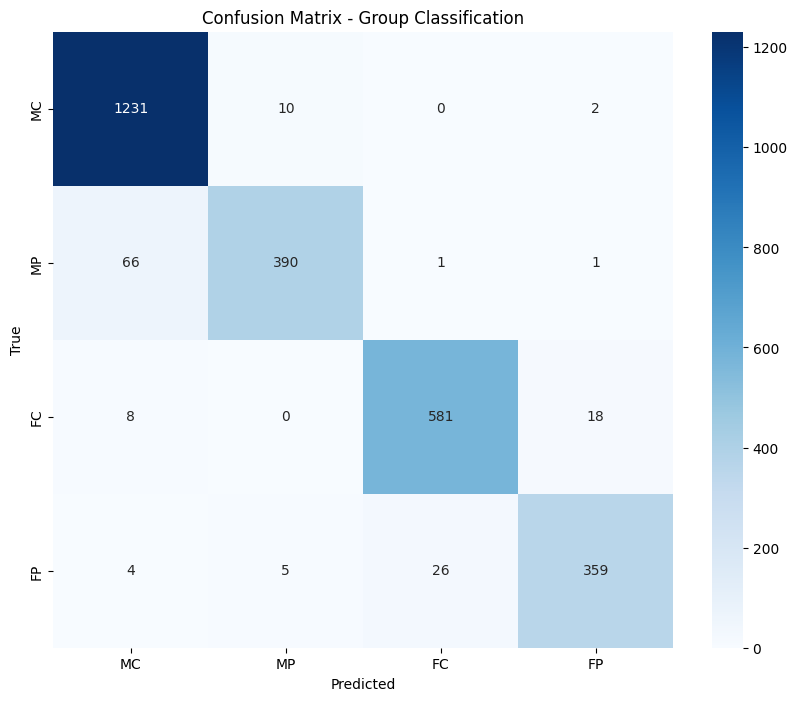

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import random
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import matthews_corrcoef, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import models
from torchvision.models import ResNet50_Weights

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Class Mapping
group_classes = {"MC": 0, "MP": 1, "FC": 2, "FP": 3}

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

def load_model(model_path, num_classes):
    model = ResNet50Classifier(num_classes=num_classes).to(device)
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    return model

def get_test_loader(test_files, test_labels, batch_size=32):
    test_dataset = MelDataset(test_files, test_labels)
    return DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Load Group Classifier
group_model = load_model("/content/MA/final_group_classifier.pth", num_classes=4)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        group = row['Group']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and group in group_classes:
            files.append(full_path)
            labels.append(group_classes[group])
        else:
            print(f"Warning: File {full_path} does not exist or invalid group.")
    return files, labels

test_set_path = os.path.join("/content/MA", "test_set.xlsx")
test_df = pd.read_excel(test_set_path)
test_files, test_labels = get_file_paths_and_labels(test_df, "/content/MA")

test_loader = get_test_loader(test_files, test_labels)

y_true, y_pred = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.numpy()
        if len(inputs.shape) == 5:
            inputs = inputs.squeeze(2)
        group_outputs = group_model(inputs)
        group_preds = torch.argmax(group_outputs, axis=1).cpu().numpy()
        y_true.extend(labels)
        y_pred.extend(group_preds)

print(f"Total samples: {len(test_labels)}")

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
mcc = matthews_corrcoef(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=group_classes.keys(),
            yticklabels=group_classes.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Group Classification")
plt.show()


In [ ]:
### classifier MP training

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet50_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

base_path = '/content/MA'
output_dir = base_path

# Class Mapping
classes = {
    "ALS": 0,
    "Covid-19": 1,
    "Dysphonie": 2,
    "Laryngitis": 3,
    "Parkinson": 4,
    "Rekurrensparese": 5
}

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32)
        if mel.ndim == 2:
            mel = mel.unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=7):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

train_set_path = os.path.join(base_path, "train_set.xlsx")
test_set_path = os.path.join(base_path, "test_set.xlsx")
train_df = pd.read_excel(train_set_path)
test_df = pd.read_excel(test_set_path)

def filter_mp_group(df):
    filtered_df = df[(df['Group'] == 'MP') & (df['Pathology'] != 'HC')]
    if filtered_df.empty:
        raise ValueError("No valid samples found after filtering for Group=MP and excluding HC.")
    return filtered_df

filtered_train_df = filter_mp_group(train_df)
filtered_test_df = filter_mp_group(test_df)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        pathology = row['Pathology']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and pathology in classes:
            files.append(full_path)
            labels.append(classes[pathology])
        else:
            print(f"Warning: File {full_path} does not exist or invalid pathology.")
    return files, labels

train_files, train_labels = get_file_paths_and_labels(filtered_train_df, base_path)
test_files, test_labels = get_file_paths_and_labels(filtered_test_df, base_path)

print(f"Filtered training samples: {len(train_files)}")
print(f"Filtered testing samples: {len(test_files)}")

test_dataset = MelDataset(test_files, test_labels)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

def plot_loss(train_losses, val_losses, fold):
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Train vs Validation Loss - Fold {fold}")
    plt.legend()
    plt.savefig(os.path.join(output_dir, f"loss_curve_fold_{fold}.png"))
    plt.close()

def save_metrics(metrics, fold):
    metrics_df = pd.DataFrame(metrics, columns=["Epoch", "MCC"])
    metrics_df.to_csv(os.path.join(output_dir, f"validation_metrics_fold_{fold}.csv"), index=False)

def save_test_metrics(fold, mcc):
    test_results_path = os.path.join(output_dir, "test_metrics_MP.csv")
    if not os.path.exists(test_results_path):
        with open(test_results_path, "w") as f:
            f.write("Fold,MCC\n")
    with open(test_results_path, "a") as f:
        f.write(f"{fold},{mcc:.4f}\n")

def evaluate_on_test_set(model, test_loader, fold):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Test Set (Fold {fold})")
    plt.savefig(os.path.join(output_dir, f"test_confusion_MP_matrix_fold_{fold}.png"))
    plt.close()

    mcc = matthews_corrcoef(y_true, y_pred)
    print(f"Test Set Results - Fold {fold}: MCC: {mcc:.4f}")
    save_test_metrics(fold, mcc)

batch_sizes = [32, 64]
learning_rates = [1e-3, 1e-4, 1e-5]
param_combinations = list(itertools.product(batch_sizes, learning_rates))
print("Hyperparameter combinations:")
for combo in param_combinations:
    print(combo)

best_params = None
best_model = None
best_val_mcc = -1

cv_results = []

for batch_size, lr in param_combinations:
    print(f"Testing parameter combination: batch_size={batch_size}, lr={lr}")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
    fold = 1
    fold_metrics = []

    for train_idx, val_idx in skf.split(train_files, train_labels):
        print(f"Starting Fold {fold} with batch_size={batch_size}, lr={lr}")

        train_dataset = MelDataset([train_files[i] for i in train_idx], [train_labels[i] for i in train_idx])
        val_dataset = MelDataset([train_files[i] for i in val_idx], [train_labels[i] for i in val_idx])
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model = ResNet50Classifier(num_classes=len(classes)).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        train_losses, val_losses = [], []

        for epoch in range(10):
            model.train()
            total_train_loss = 0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item()

            model.eval()
            total_val_loss = 0
            y_true, y_pred = [], []
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    total_val_loss += loss.item()
                    y_true.extend(labels.cpu().numpy())
                    y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

            train_loss = total_train_loss / len(train_loader)
            val_loss = total_val_loss / len(val_loader)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

        mcc = matthews_corrcoef(y_true, y_pred)
        fold_metrics.append(mcc)
        print(f"Fold {fold} | MCC: {mcc:.4f}")
        fold += 1

    avg_mcc = sum(fold_metrics) / len(fold_metrics)
    cv_results.append((batch_size, lr, avg_mcc))

    if avg_mcc > best_val_mcc:
        best_val_mcc = avg_mcc
        best_params = (batch_size, lr)
        best_model = model

print(f"Best parameters: batch_size={best_params[0]}, lr={best_params[1]} with MCC={best_val_mcc:.4f}")

# Retrain based on whole test set
print("Retraining model with best parameters on full training set...")
final_train_dataset = MelDataset(train_files, train_labels)
final_train_loader = DataLoader(final_train_dataset, batch_size=best_params[0], shuffle=True)
final_model = ResNet50Classifier(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params[1])

for epoch in range(10):
    final_model.train()
    total_train_loss = 0
    for inputs, labels in final_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = final_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(final_train_loader)
    print(f"Retrain Epoch {epoch + 1}: Train Loss: {avg_train_loss:.4f}")

model_save_path = os.path.join(output_dir, "best_resnet50_MP_model.pth")
torch.save(final_model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

print("Evaluating final model on test set...")
evaluate_on_test_set(final_model, test_loader, "Final")


Using device: cuda
Filtered training samples: 5589
Filtered testing samples: 458
Hyperparameter combinations:
(32, 0.001)
(32, 0.0001)
(32, 1e-05)
(64, 0.001)
(64, 0.0001)
(64, 1e-05)
Testing parameter combination: batch_size=32, lr=0.001
Starting Fold 1 with batch_size=32, lr=0.001


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 215MB/s]


Epoch 1: Train Loss: 0.6363, Validation Loss: 0.3889
Epoch 2: Train Loss: 0.3706, Validation Loss: 0.3473
Epoch 3: Train Loss: 0.2086, Validation Loss: 0.2186
Epoch 4: Train Loss: 0.1862, Validation Loss: 0.1506
Epoch 5: Train Loss: 0.1188, Validation Loss: 0.1249
Epoch 6: Train Loss: 0.1121, Validation Loss: 0.1289
Epoch 7: Train Loss: 0.0774, Validation Loss: 0.2324
Epoch 8: Train Loss: 0.0411, Validation Loss: 0.0958
Epoch 9: Train Loss: 0.0444, Validation Loss: 0.0835
Epoch 10: Train Loss: 0.0502, Validation Loss: 0.1786
Fold 1 | MCC: 0.9535
Starting Fold 2 with batch_size=32, lr=0.001
Epoch 1: Train Loss: 0.6771, Validation Loss: 0.7473
Epoch 2: Train Loss: 0.3569, Validation Loss: 0.3944
Epoch 3: Train Loss: 0.2097, Validation Loss: 0.1353
Epoch 4: Train Loss: 0.1399, Validation Loss: 0.0741
Epoch 5: Train Loss: 0.1430, Validation Loss: 0.0970
Epoch 6: Train Loss: 0.0710, Validation Loss: 0.2247
Epoch 7: Train Loss: 0.0787, Validation Loss: 0.1852
Epoch 8: Train Loss: 0.0734, Val

In [ ]:
### classifier MP test

<ipython-input-4-5a625e53b0fb>:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load('/content/MA/best_resnet50_MP_model.pth'))


Precision: 0.9783
Recall: 0.9782
F1 Score: 0.9779
MCC: 0.9657


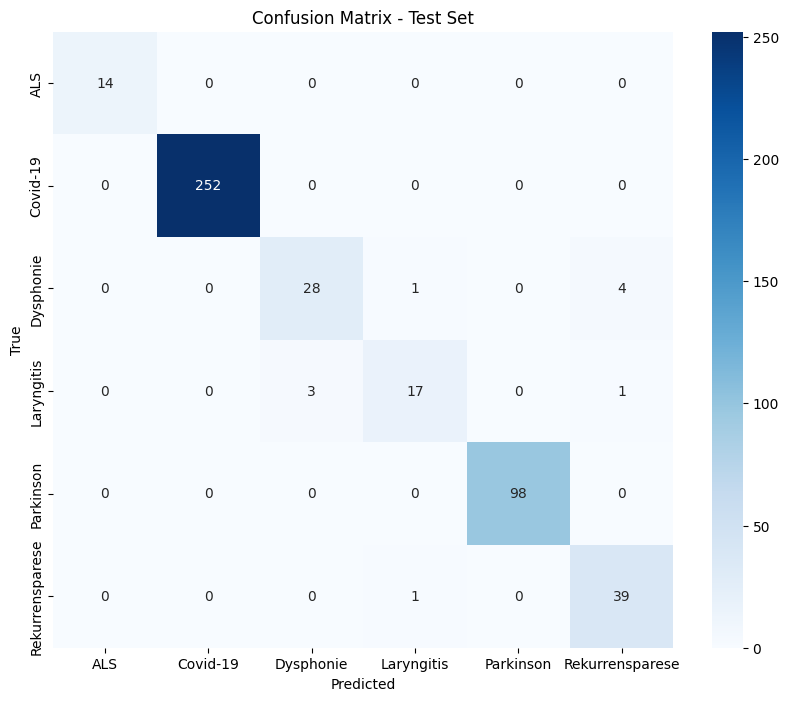

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model_on_test_set(model, test_loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            predictions = torch.argmax(outputs, axis=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix - Test Set")
    plt.show()

    return precision, recall, f1, mcc

final_model.load_state_dict(torch.load('/content/MA/best_resnet50_MP_model.pth'))
final_model.to(device)

precision, recall, f1, mcc = evaluate_model_on_test_set(final_model, test_loader)

In [ ]:
## classifier FP training

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet50_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import itertools


random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

base_path = '/content/MA'
output_dir = base_path

# Class Mapping
classes = {
    "ALS": 0,
    "Covid-19": 1,
    "Dysphonie": 2,
    "Laryngitis": 3,
    "Parkinson": 4,
    "Rekurrensparese": 5
}

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32)
        if mel.ndim == 2:
            mel = mel.unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=7):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

train_set_path = os.path.join(base_path, "train_set.xlsx")
test_set_path = os.path.join(base_path, "test_set.xlsx")
train_df = pd.read_excel(train_set_path)
test_df = pd.read_excel(test_set_path)

def filter_mp_group(df):
    filtered_df = df[(df['Group'] == 'FP') & (df['Pathology'] != 'HC')]
    if filtered_df.empty:
        raise ValueError("No valid samples found after filtering for Group=FP and excluding HC.")
    return filtered_df

filtered_train_df = filter_mp_group(train_df)
filtered_test_df = filter_mp_group(test_df)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        pathology = row['Pathology']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and pathology in classes:
            files.append(full_path)
            labels.append(classes[pathology])
        else:
            print(f"Warning: File {full_path} does not exist or invalid pathology.")
    return files, labels

train_files, train_labels = get_file_paths_and_labels(filtered_train_df, base_path)
test_files, test_labels = get_file_paths_and_labels(filtered_test_df, base_path)

print(f"Filtered training samples: {len(train_files)}")
print(f"Filtered testing samples: {len(test_files)}")

test_dataset = MelDataset(test_files, test_labels)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

def plot_loss(train_losses, val_losses, fold):
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Train vs Validation Loss - Fold {fold}")
    plt.legend()
    plt.savefig(os.path.join(output_dir, f"loss_curve_fold_{fold}.png"))
    plt.close()

def save_metrics(metrics, fold):
    metrics_df = pd.DataFrame(metrics, columns=["Epoch", "MCC"])
    metrics_df.to_csv(os.path.join(output_dir, f"validation_metrics_fold_{fold}.csv"), index=False)

def save_test_metrics(fold, mcc):
    test_results_path = os.path.join(output_dir, "test_metrics_FP.csv")
    if not os.path.exists(test_results_path):
        with open(test_results_path, "w") as f:
            f.write("Fold,MCC\n")
    with open(test_results_path, "a") as f:
        f.write(f"{fold},{mcc:.4f}\n")

def evaluate_on_test_set(model, test_loader, fold):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Test Set (Fold {fold})")
    plt.savefig(os.path.join(output_dir, f"test_confusion_FP_matrix_fold_{fold}.png"))
    plt.close()

    mcc = matthews_corrcoef(y_true, y_pred)
    print(f"Test Set Results - Fold {fold}: MCC: {mcc:.4f}")
    save_test_metrics(fold, mcc)

batch_sizes = [32, 64]
learning_rates = [1e-3, 1e-4, 1e-5]
param_combinations = list(itertools.product(batch_sizes, learning_rates))
print("Hyperparameter combinations:")
for combo in param_combinations:
    print(combo)

best_params = None
best_model = None
best_val_mcc = -1

cv_results = []

for batch_size, lr in param_combinations:
    print(f"Testing parameter combination: batch_size={batch_size}, lr={lr}")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
    fold = 1
    fold_metrics = []

    for train_idx, val_idx in skf.split(train_files, train_labels):
        print(f"Starting Fold {fold} with batch_size={batch_size}, lr={lr}")

        train_dataset = MelDataset([train_files[i] for i in train_idx], [train_labels[i] for i in train_idx])
        val_dataset = MelDataset([train_files[i] for i in val_idx], [train_labels[i] for i in val_idx])
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model = ResNet50Classifier(num_classes=len(classes)).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        train_losses, val_losses = [], []

        for epoch in range(10):
            model.train()
            total_train_loss = 0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item()

            model.eval()
            total_val_loss = 0
            y_true, y_pred = [], []
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    total_val_loss += loss.item()
                    y_true.extend(labels.cpu().numpy())
                    y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

            train_loss = total_train_loss / len(train_loader)
            val_loss = total_val_loss / len(val_loader)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

        mcc = matthews_corrcoef(y_true, y_pred)
        fold_metrics.append(mcc)
        print(f"Fold {fold} | MCC: {mcc:.4f}")
        fold += 1

    avg_mcc = sum(fold_metrics) / len(fold_metrics)
    cv_results.append((batch_size, lr, avg_mcc))

    if avg_mcc > best_val_mcc:
        best_val_mcc = avg_mcc
        best_params = (batch_size, lr)
        best_model = model

print(f"Best parameters: batch_size={best_params[0]}, lr={best_params[1]} with MCC={best_val_mcc:.4f}")

# Retrain on whole training set
print("Retraining model with best parameters on full training set...")
final_train_dataset = MelDataset(train_files, train_labels)
final_train_loader = DataLoader(final_train_dataset, batch_size=best_params[0], shuffle=True)
final_model = ResNet50Classifier(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params[1])

for epoch in range(10):
    final_model.train()
    total_train_loss = 0
    for inputs, labels in final_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = final_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(final_train_loader)
    print(f"Retrain Epoch {epoch + 1}: Train Loss: {avg_train_loss:.4f}")

model_save_path = os.path.join(output_dir, "best_resnet50_FP_model.pth")
torch.save(final_model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

print("Evaluating final model on test set...")
evaluate_on_test_set(final_model, test_loader, "Final")


Using device: cuda
Filtered training samples: 3424
Filtered testing samples: 394
Hyperparameter combinations:
(32, 0.001)
(32, 0.0001)
(32, 1e-05)
(64, 0.001)
(64, 0.0001)
(64, 1e-05)
Testing parameter combination: batch_size=32, lr=0.001
Starting Fold 1 with batch_size=32, lr=0.001


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]


Epoch 1: Train Loss: 0.7106, Validation Loss: 0.7571
Epoch 2: Train Loss: 0.5505, Validation Loss: 0.9816
Epoch 3: Train Loss: 0.3964, Validation Loss: 0.4478
Epoch 4: Train Loss: 0.3316, Validation Loss: 0.4444
Epoch 5: Train Loss: 0.2638, Validation Loss: 0.2920
Epoch 6: Train Loss: 0.2279, Validation Loss: 0.4558
Epoch 7: Train Loss: 0.1615, Validation Loss: 0.1506
Epoch 8: Train Loss: 0.1241, Validation Loss: 0.1758
Epoch 9: Train Loss: 0.1064, Validation Loss: 0.3914
Epoch 10: Train Loss: 0.1448, Validation Loss: 0.3179
Fold 1 | MCC: 0.8785
Starting Fold 2 with batch_size=32, lr=0.001
Epoch 1: Train Loss: 0.7400, Validation Loss: 0.9122
Epoch 2: Train Loss: 0.4624, Validation Loss: 0.5331
Epoch 3: Train Loss: 0.4028, Validation Loss: 0.4309
Epoch 4: Train Loss: 0.3218, Validation Loss: 0.3108
Epoch 5: Train Loss: 0.2375, Validation Loss: 0.2934
Epoch 6: Train Loss: 0.2578, Validation Loss: 0.3623
Epoch 7: Train Loss: 0.1767, Validation Loss: 0.1854
Epoch 8: Train Loss: 0.1883, Val

In [ ]:
### classifier FP test

<ipython-input-4-193dd2f226d0>:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load('/content/MA/best_resnet50_FP_model.pth'))


Precision: 0.9440
Recall: 0.9416
F1 Score: 0.9422
MCC: 0.9226


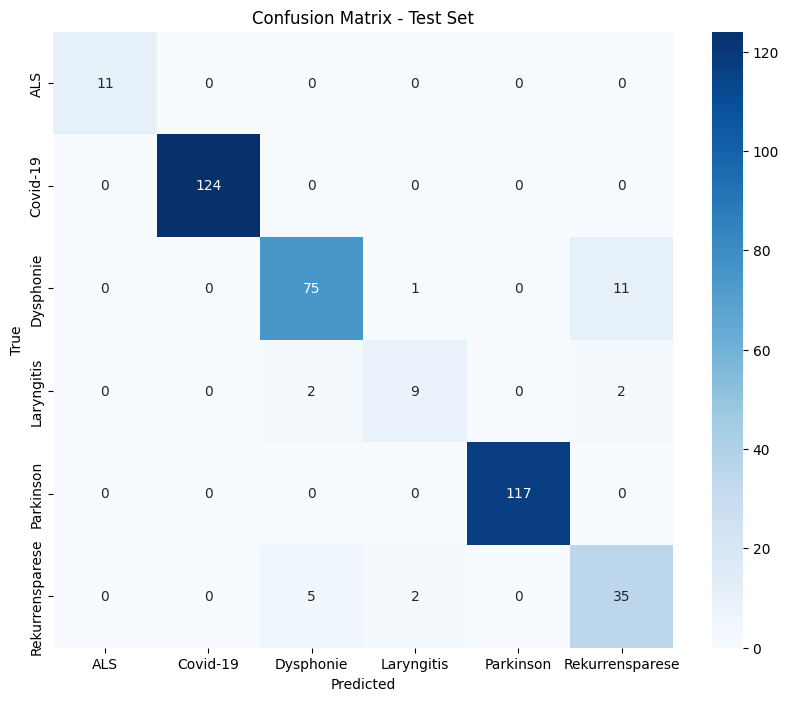

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model_on_test_set(model, test_loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            predictions = torch.argmax(outputs, axis=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix - Test Set")
    plt.show()

    return precision, recall, f1, mcc

final_model.load_state_dict(torch.load('/content/MA/best_resnet50_FP_model.pth'))
final_model.to(device)

precision, recall, f1, mcc = evaluate_model_on_test_set(final_model, test_loader)

In [ ]:
### two stage architecture test

Using device: cuda


<ipython-input-7-c5a47238f324>:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=device)


Total samples: 2702
Samples classified as HC: 1916
Precision: 0.9447
Recall: 0.9456
F1 Score: 0.9442
MCC: 0.8896


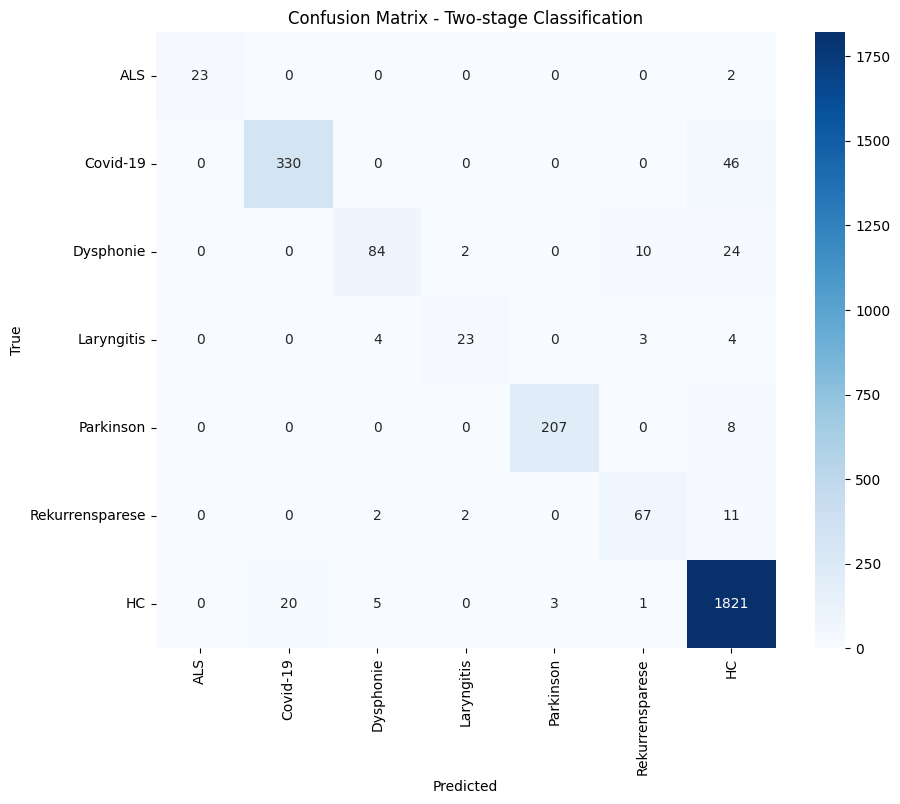

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import random
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import matthews_corrcoef, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import models
from torchvision.models import ResNet50_Weights

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Class Mapping
group_classes = {"MC": 0, "MP": 1, "FC": 2, "FP": 3}
disease_classes = {
    "ALS": 0,
    "Covid-19": 1,
    "Dysphonie": 2,
    "Laryngitis": 3,
    "Parkinson": 4,
    "Rekurrensparese": 5,
    "HC": 6
}

#  Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

def load_model(model_path, num_classes):
    model = ResNet50Classifier(num_classes=num_classes).to(device)
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    return model

def get_test_loader(test_files, test_labels, batch_size=32):
    test_dataset = MelDataset(test_files, test_labels)
    return DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Load Group Classifier
group_model = load_model("/content/MA/final_group_classifier.pth", num_classes=4)

# Load MP and FP Classifier
mp_model = load_model("/content/MA/best_resnet50_MP_model.pth", num_classes=6)
fp_model = load_model("/content/MA/best_resnet50_FP_model.pth", num_classes=6)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        pathology = row['Pathology']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and pathology in disease_classes:
            files.append(full_path)
            labels.append(disease_classes[pathology])
        else:
            print(f"Warning: File {full_path} does not exist or invalid pathology.")
    return files, labels

test_set_path = os.path.join("/content/MA", "test_set.xlsx")
test_df = pd.read_excel(test_set_path)
test_files, test_labels = get_file_paths_and_labels(test_df, "/content/MA")

test_loader = get_test_loader(test_files, test_labels)

y_true, y_pred = [], []

total_samples, mc_fc_count = 0, 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.numpy()
        if len(inputs.shape) == 5:
            inputs = inputs.squeeze(2)
        group_outputs = group_model(inputs)
        group_preds = torch.argmax(group_outputs, axis=1).cpu().numpy()

        for i, group_pred in enumerate(group_preds):
            if group_pred in [group_classes["MC"], group_classes["FC"]]:
                y_true.append(labels[i])
                y_pred.append(disease_classes["HC"])
                mc_fc_count += 1
            elif group_pred == group_classes["MP"]:
                mp_output = mp_model(inputs[i].unsqueeze(0))
                mp_pred = torch.argmax(mp_output, axis=1).cpu().item()
                y_true.append(labels[i])
                y_pred.append(mp_pred)
            elif group_pred == group_classes["FP"]:
                fp_output = fp_model(inputs[i].unsqueeze(0))
                fp_pred = torch.argmax(fp_output, axis=1).cpu().item()
                y_true.append(labels[i])
                y_pred.append(fp_pred)

print(f"Total samples: {len(test_labels)}")
print(f"Samples classified as HC: {mc_fc_count}")

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
mcc = matthews_corrcoef(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=disease_classes.keys(),
            yticklabels=disease_classes.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Two-stage Classification")
plt.show()


In [ ]:
### EXP 3.2 Timewarp based two stage architecture

In [ ]:
### classifier PD training

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet50_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

base_path = '/content/MA'
output_dir = base_path

# Class Mapping
classes = {
    "MC": 0,  # Male Control
    "MP": 1,  # Male Pathology
    "FC": 2,  # Female Control
    "FP": 3   # Female Pathology
}

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32)
        if mel.ndim == 2:
            mel = mel.unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=4):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        group = row['Group']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and group in classes:
            files.append(full_path)
            labels.append(classes[group])
        else:
            print(f"Warning: File {full_path} does not exist or invalid group.")
    return files, labels

train_set_path = os.path.join(base_path, "train_set.xlsx")
test_set_path = os.path.join(base_path, "test_set.xlsx")
train_df = pd.read_excel(train_set_path)
test_df = pd.read_excel(test_set_path)

train_files, train_labels = get_file_paths_and_labels(train_df, base_path)
test_files, test_labels = get_file_paths_and_labels(test_df, base_path)

test_dataset = MelDataset(test_files, test_labels)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

def plot_loss(train_losses, val_losses, fold):
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Train vs Validation Loss - Fold {fold}")
    plt.legend()
    plt.savefig(os.path.join(output_dir, f"loss_curve_fold_{fold}.png"))
    plt.close()

def save_metrics(metrics, fold):
    metrics_df = pd.DataFrame(metrics, columns=["Epoch", "MCC"])
    metrics_df.to_csv(os.path.join(output_dir, f"validation_metrics_fold_{fold}.csv"), index=False)

def save_test_metrics(fold, mcc):
    test_results_path = os.path.join(output_dir, "test_metrics.csv")
    if not os.path.exists(test_results_path):
        with open(test_results_path, "w") as f:
            f.write("Fold,MCC\n")
    with open(test_results_path, "a") as f:
        f.write(f"{fold},{mcc:.4f}\n")

def evaluate_on_test_set(model, test_loader, fold):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Test Set (Fold {fold})")
    plt.savefig(os.path.join(output_dir, f"test_confusion_matrix_fold_{fold}.png"))
    plt.close()

    mcc = matthews_corrcoef(y_true, y_pred)
    print(f"Test Set Results - Fold {fold}: MCC: {mcc:.4f}")
    save_test_metrics(fold, mcc)

batch_sizes = [32, 64]
learning_rates = [1e-3, 1e-4, 1e-5]
param_combinations = list(itertools.product(batch_sizes, learning_rates))

best_params = None
best_model = None
best_val_mcc = -1

cv_results = []

for batch_size, lr in param_combinations:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
    fold = 1

    last_mcc_values = []

    for train_idx, val_idx in skf.split(train_files, train_labels):
        print(f"Starting Fold {fold} with batch_size={batch_size}, lr={lr}")

        train_dataset = MelDataset([train_files[i] for i in train_idx], [train_labels[i] for i in train_idx])
        val_dataset = MelDataset([train_files[i] for i in val_idx], [train_labels[i] for i in val_idx])
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model = ResNet50Classifier(num_classes=len(classes)).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        train_losses, val_losses = [], []

        for epoch in range(10):
            model.train()
            total_train_loss = 0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item()

            model.eval()
            total_val_loss = 0
            y_true, y_pred = [], []
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    total_val_loss += loss.item()
                    y_true.extend(labels.cpu().numpy())
                    y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

            train_loss = total_train_loss / len(train_loader)
            val_loss = total_val_loss / len(val_loader)
            train_losses.append(train_loss)
            val_losses.append(val_loss)

            print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

        last_mcc = matthews_corrcoef(y_true, y_pred)
        last_mcc_values.append(last_mcc)
        print(f"Fold {fold} | MCC: {last_mcc:.4f}")
        fold += 1

    avg_mcc = np.mean(last_mcc_values)
    print(f"Average MCC for batch_size={batch_size}, lr={lr}: {avg_mcc:.4f}")

    if avg_mcc > best_val_mcc:
        best_val_mcc = avg_mcc
        best_params = (batch_size, lr)
        best_model = model

print(f"Best Parameters: batch_size={best_params[0]}, lr={best_params[1]} with MCC={best_val_mcc:.4f}")

# retrain on whole training set
final_train_dataset = MelDataset(train_files, train_labels)
final_train_loader = DataLoader(final_train_dataset, batch_size=best_params[0], shuffle=True)
final_model = ResNet50Classifier(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params[1])

train_losses = []

for epoch in range(10):
    final_model.train()
    total_train_loss = 0
    for inputs, labels in final_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = final_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(final_train_loader)
    train_losses.append(avg_train_loss)
    print(f"Retrain Epoch {epoch + 1}: Train Loss: {avg_train_loss:.4f}")

final_model_save_path = os.path.join(output_dir, "final_group_classifier.pth")
torch.save(final_model.state_dict(), final_model_save_path)
print(f"Final model saved to {final_model_save_path}")

final_model.load_state_dict(torch.load(final_model_save_path))
evaluate_on_test_set(final_model, test_loader, "Final")


Using device: cuda
Starting Fold 1 with batch_size=32, lr=0.001


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]


Epoch 1: Train Loss: 0.7024, Validation Loss: 0.5667
Epoch 2: Train Loss: 0.4668, Validation Loss: 0.4283
Epoch 3: Train Loss: 0.3380, Validation Loss: 0.2833
Epoch 4: Train Loss: 0.2491, Validation Loss: 0.2271
Epoch 5: Train Loss: 0.1841, Validation Loss: 0.1987
Epoch 6: Train Loss: 0.1511, Validation Loss: 0.1948
Epoch 7: Train Loss: 0.1258, Validation Loss: 0.1433
Epoch 8: Train Loss: 0.1016, Validation Loss: 0.2178
Epoch 9: Train Loss: 0.0853, Validation Loss: 0.1645
Epoch 10: Train Loss: 0.0789, Validation Loss: 0.1298
Fold 1 | MCC: 0.9456
Starting Fold 2 with batch_size=32, lr=0.001
Epoch 1: Train Loss: 0.6898, Validation Loss: 0.4988
Epoch 2: Train Loss: 0.4574, Validation Loss: 0.3961
Epoch 3: Train Loss: 0.3327, Validation Loss: 0.3007
Epoch 4: Train Loss: 0.2393, Validation Loss: 0.2280
Epoch 5: Train Loss: 0.1820, Validation Loss: 0.1952
Epoch 6: Train Loss: 0.1587, Validation Loss: 0.1664
Epoch 7: Train Loss: 0.1173, Validation Loss: 0.1913
Epoch 8: Train Loss: 0.1068, Val

<ipython-input-2-29c3fe41e40e>:257: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load(final_model_save_path))


Test Set Results - Fold Final: MCC: 0.9431


In [ ]:
## classifier PD test

<ipython-input-3-99cc715392d4>:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load('/content/MA/final_group_classifier.pth'))


Precision: 0.9613
Recall: 0.9608
F1 Score: 0.9603
MCC: 0.9431


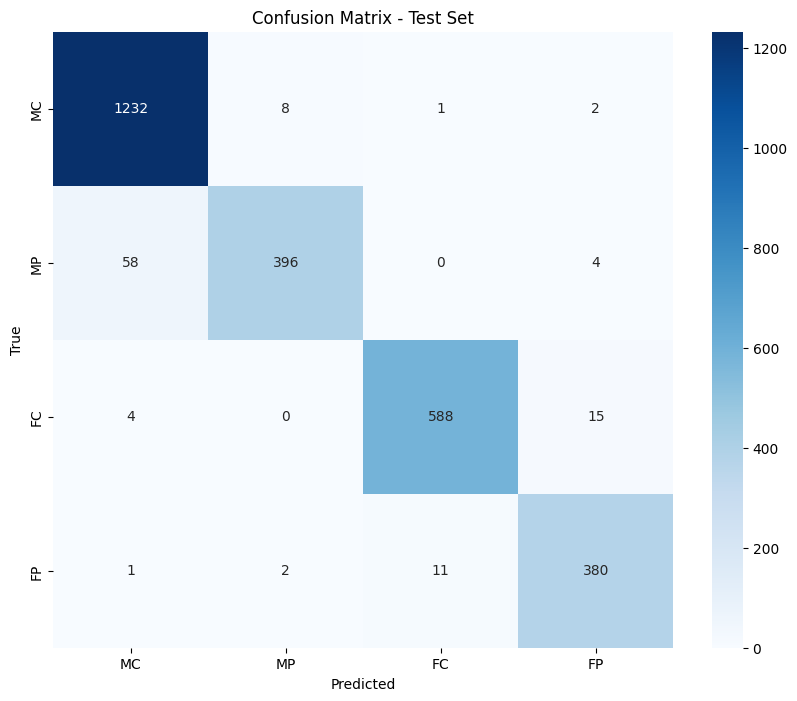

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model_on_test_set(model, test_loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            predictions = torch.argmax(outputs, axis=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix - Test Set")
    plt.show()

    return precision, recall, f1, mcc

final_model.load_state_dict(torch.load('/content/MA/final_group_classifier.pth'))
final_model.to(device)

precision, recall, f1, mcc = evaluate_model_on_test_set(final_model, test_loader)


In [ ]:
### classifier MP training

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet50_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

base_path = '/content/MA'
output_dir = base_path

# Class Mapping
classes = {
    "ALS": 0,
    "Covid-19": 1,
    "Dysphonie": 2,
    "Laryngitis": 3,
    "Parkinson": 4,
    "Rekurrensparese": 5
}

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32)
        if mel.ndim == 2:
            mel = mel.unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=7):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

train_set_path = os.path.join(base_path, "train_set.xlsx")
test_set_path = os.path.join(base_path, "test_set.xlsx")
train_df = pd.read_excel(train_set_path)
test_df = pd.read_excel(test_set_path)

def filter_mp_group(df):
    filtered_df = df[(df['Group'] == 'MP') & (df['Pathology'] != 'HC')]
    if filtered_df.empty:
        raise ValueError("No valid samples found after filtering for Group=MP and excluding HC.")
    return filtered_df

filtered_train_df = filter_mp_group(train_df)
filtered_test_df = filter_mp_group(test_df)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        pathology = row['Pathology']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and pathology in classes:
            files.append(full_path)
            labels.append(classes[pathology])
        else:
            print(f"Warning: File {full_path} does not exist or invalid pathology.")
    return files, labels

train_files, train_labels = get_file_paths_and_labels(filtered_train_df, base_path)
test_files, test_labels = get_file_paths_and_labels(filtered_test_df, base_path)

print(f"Filtered training samples: {len(train_files)}")
print(f"Filtered testing samples: {len(test_files)}")

test_dataset = MelDataset(test_files, test_labels)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

def plot_loss(train_losses, val_losses, fold):
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Train vs Validation Loss - Fold {fold}")
    plt.legend()
    plt.savefig(os.path.join(output_dir, f"loss_curve_fold_{fold}.png"))
    plt.close()

def save_metrics(metrics, fold):
    metrics_df = pd.DataFrame(metrics, columns=["Epoch", "MCC"])
    metrics_df.to_csv(os.path.join(output_dir, f"validation_metrics_fold_{fold}.csv"), index=False)

def save_test_metrics(fold, mcc):
    test_results_path = os.path.join(output_dir, "test_metrics_MP.csv")
    if not os.path.exists(test_results_path):
        with open(test_results_path, "w") as f:
            f.write("Fold,MCC\n")
    with open(test_results_path, "a") as f:
        f.write(f"{fold},{mcc:.4f}\n")

def evaluate_on_test_set(model, test_loader, fold):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Test Set (Fold {fold})")
    plt.savefig(os.path.join(output_dir, f"test_confusion_MP_matrix_fold_{fold}.png"))
    plt.close()

    mcc = matthews_corrcoef(y_true, y_pred)
    print(f"Test Set Results - Fold {fold}: MCC: {mcc:.4f}")
    save_test_metrics(fold, mcc)

batch_sizes = [32, 64]
learning_rates = [1e-3, 1e-4, 1e-5]
param_combinations = list(itertools.product(batch_sizes, learning_rates))
print("Hyperparameter combinations:")
for combo in param_combinations:
    print(combo)

best_params = None
best_model = None
best_val_mcc = -1

cv_results = []

for batch_size, lr in param_combinations:
    print(f"Testing parameter combination: batch_size={batch_size}, lr={lr}")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
    fold = 1
    fold_metrics = []

    for train_idx, val_idx in skf.split(train_files, train_labels):
        print(f"Starting Fold {fold} with batch_size={batch_size}, lr={lr}")

        train_dataset = MelDataset([train_files[i] for i in train_idx], [train_labels[i] for i in train_idx])
        val_dataset = MelDataset([train_files[i] for i in val_idx], [train_labels[i] for i in val_idx])
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model = ResNet50Classifier(num_classes=len(classes)).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        train_losses, val_losses = [], []

        for epoch in range(10):
            model.train()
            total_train_loss = 0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item()

            model.eval()
            total_val_loss = 0
            y_true, y_pred = [], []
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    total_val_loss += loss.item()
                    y_true.extend(labels.cpu().numpy())
                    y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

            train_loss = total_train_loss / len(train_loader)
            val_loss = total_val_loss / len(val_loader)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

        mcc = matthews_corrcoef(y_true, y_pred)
        fold_metrics.append(mcc)
        print(f"Fold {fold} | MCC: {mcc:.4f}")
        fold += 1

    avg_mcc = sum(fold_metrics) / len(fold_metrics)
    cv_results.append((batch_size, lr, avg_mcc))

    if avg_mcc > best_val_mcc:
        best_val_mcc = avg_mcc
        best_params = (batch_size, lr)
        best_model = model

print(f"Best parameters: batch_size={best_params[0]}, lr={best_params[1]} with MCC={best_val_mcc:.4f}")

# retrain on whole training set
print("Retraining model with best parameters on full training set...")
final_train_dataset = MelDataset(train_files, train_labels)
final_train_loader = DataLoader(final_train_dataset, batch_size=best_params[0], shuffle=True)
final_model = ResNet50Classifier(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params[1])

for epoch in range(10):
    final_model.train()
    total_train_loss = 0
    for inputs, labels in final_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = final_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(final_train_loader)
    print(f"Retrain Epoch {epoch + 1}: Train Loss: {avg_train_loss:.4f}")

model_save_path = os.path.join(output_dir, "best_resnet50_MP_model.pth")
torch.save(final_model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

print("Evaluating final model on test set...")
evaluate_on_test_set(final_model, test_loader, "Final")


Using device: cuda
Filtered training samples: 5599
Filtered testing samples: 458
Hyperparameter combinations:
(32, 0.001)
(32, 0.0001)
(32, 1e-05)
(64, 0.001)
(64, 0.0001)
(64, 1e-05)
Testing parameter combination: batch_size=32, lr=0.001
Starting Fold 1 with batch_size=32, lr=0.001


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 202MB/s]


Epoch 1: Train Loss: 0.5925, Validation Loss: 1.1733
Epoch 2: Train Loss: 0.1877, Validation Loss: 0.2715
Epoch 3: Train Loss: 0.1305, Validation Loss: 0.0956
Epoch 4: Train Loss: 0.1045, Validation Loss: 0.3856
Epoch 5: Train Loss: 0.0639, Validation Loss: 0.0945
Epoch 6: Train Loss: 0.0448, Validation Loss: 0.0058
Epoch 7: Train Loss: 0.0103, Validation Loss: 0.0892
Epoch 8: Train Loss: 0.0395, Validation Loss: 0.0848
Epoch 9: Train Loss: 0.0827, Validation Loss: 0.0089
Epoch 10: Train Loss: 0.0244, Validation Loss: 0.1348
Fold 1 | MCC: 0.9515
Starting Fold 2 with batch_size=32, lr=0.001
Epoch 1: Train Loss: 0.5442, Validation Loss: 0.7474
Epoch 2: Train Loss: 0.2067, Validation Loss: 0.0856
Epoch 3: Train Loss: 0.1410, Validation Loss: 0.3681
Epoch 4: Train Loss: 0.0415, Validation Loss: 0.0120
Epoch 5: Train Loss: 0.0823, Validation Loss: 0.2504
Epoch 6: Train Loss: 0.0485, Validation Loss: 0.0234
Epoch 7: Train Loss: 0.0481, Validation Loss: 0.0019
Epoch 8: Train Loss: 0.0278, Val

In [ ]:
### classifier MP test

<ipython-input-3-5a625e53b0fb>:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load('/content/MA/best_resnet50_MP_model.pth'))


Precision: 0.9913
Recall: 0.9913
F1 Score: 0.9911
MCC: 0.9863


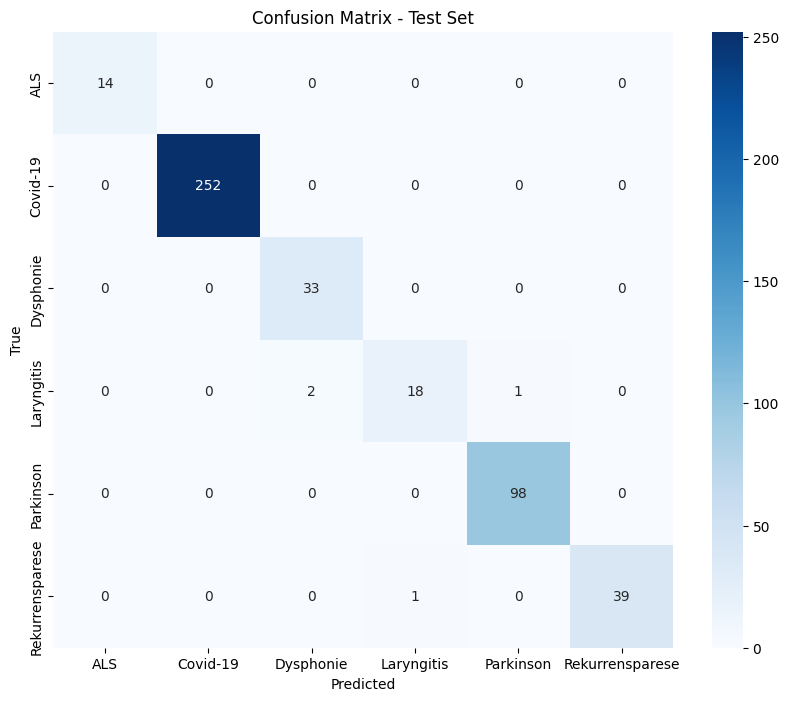

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model_on_test_set(model, test_loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            predictions = torch.argmax(outputs, axis=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix - Test Set")
    plt.show()

    return precision, recall, f1, mcc

final_model.load_state_dict(torch.load('/content/MA/best_resnet50_MP_model.pth'))
final_model.to(device)

precision, recall, f1, mcc = evaluate_model_on_test_set(final_model, test_loader)

In [ ]:
## classifier FP training

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet50_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import itertools


random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

base_path = '/content/MA'
output_dir = base_path

# Class Mapping
classes = {
    "ALS": 0,
    "Covid-19": 1,
    "Dysphonie": 2,
    "Laryngitis": 3,
    "Parkinson": 4,
    "Rekurrensparese": 5
}

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32)
        if mel.ndim == 2:
            mel = mel.unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=7):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

train_set_path = os.path.join(base_path, "train_set.xlsx")
test_set_path = os.path.join(base_path, "test_set.xlsx")
train_df = pd.read_excel(train_set_path)
test_df = pd.read_excel(test_set_path)

def filter_mp_group(df):
    filtered_df = df[(df['Group'] == 'FP') & (df['Pathology'] != 'HC')]
    if filtered_df.empty:
        raise ValueError("No valid samples found after filtering for Group=FP and excluding HC.")
    return filtered_df

filtered_train_df = filter_mp_group(train_df)
filtered_test_df = filter_mp_group(test_df)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        pathology = row['Pathology']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and pathology in classes:
            files.append(full_path)
            labels.append(classes[pathology])
        else:
            print(f"Warning: File {full_path} does not exist or invalid pathology.")
    return files, labels

train_files, train_labels = get_file_paths_and_labels(filtered_train_df, base_path)
test_files, test_labels = get_file_paths_and_labels(filtered_test_df, base_path)

print(f"Filtered training samples: {len(train_files)}")
print(f"Filtered testing samples: {len(test_files)}")

test_dataset = MelDataset(test_files, test_labels)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

def plot_loss(train_losses, val_losses, fold):
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Train vs Validation Loss - Fold {fold}")
    plt.legend()
    plt.savefig(os.path.join(output_dir, f"loss_curve_fold_{fold}.png"))
    plt.close()

def save_metrics(metrics, fold):
    metrics_df = pd.DataFrame(metrics, columns=["Epoch", "MCC"])
    metrics_df.to_csv(os.path.join(output_dir, f"validation_metrics_fold_{fold}.csv"), index=False)

def save_test_metrics(fold, mcc):
    test_results_path = os.path.join(output_dir, "test_metrics_FP.csv")
    if not os.path.exists(test_results_path):
        with open(test_results_path, "w") as f:
            f.write("Fold,MCC\n")
    with open(test_results_path, "a") as f:
        f.write(f"{fold},{mcc:.4f}\n")

def evaluate_on_test_set(model, test_loader, fold):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Test Set (Fold {fold})")
    plt.savefig(os.path.join(output_dir, f"test_confusion_FP_matrix_fold_{fold}.png"))
    plt.close()

    mcc = matthews_corrcoef(y_true, y_pred)
    print(f"Test Set Results - Fold {fold}: MCC: {mcc:.4f}")
    save_test_metrics(fold, mcc)

batch_sizes = [32, 64]
learning_rates = [1e-3, 1e-4, 1e-5]
param_combinations = list(itertools.product(batch_sizes, learning_rates))
print("Hyperparameter combinations:")
for combo in param_combinations:
    print(combo)

best_params = None
best_model = None
best_val_mcc = -1

cv_results = []

for batch_size, lr in param_combinations:
    print(f"Testing parameter combination: batch_size={batch_size}, lr={lr}")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
    fold = 1
    fold_metrics = []

    for train_idx, val_idx in skf.split(train_files, train_labels):
        print(f"Starting Fold {fold} with batch_size={batch_size}, lr={lr}")

        train_dataset = MelDataset([train_files[i] for i in train_idx], [train_labels[i] for i in train_idx])
        val_dataset = MelDataset([train_files[i] for i in val_idx], [train_labels[i] for i in val_idx])
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model = ResNet50Classifier(num_classes=len(classes)).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        train_losses, val_losses = [], []

        for epoch in range(10):
            model.train()
            total_train_loss = 0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item()

            model.eval()
            total_val_loss = 0
            y_true, y_pred = [], []
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    total_val_loss += loss.item()
                    y_true.extend(labels.cpu().numpy())
                    y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

            train_loss = total_train_loss / len(train_loader)
            val_loss = total_val_loss / len(val_loader)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

        mcc = matthews_corrcoef(y_true, y_pred)
        fold_metrics.append(mcc)
        print(f"Fold {fold} | MCC: {mcc:.4f}")
        fold += 1

    avg_mcc = sum(fold_metrics) / len(fold_metrics)
    cv_results.append((batch_size, lr, avg_mcc))

    if avg_mcc > best_val_mcc:
        best_val_mcc = avg_mcc
        best_params = (batch_size, lr)
        best_model = model

print(f"Best parameters: batch_size={best_params[0]}, lr={best_params[1]} with MCC={best_val_mcc:.4f}")

# Retrain on whole training set
print("Retraining model with best parameters on full training set...")
final_train_dataset = MelDataset(train_files, train_labels)
final_train_loader = DataLoader(final_train_dataset, batch_size=best_params[0], shuffle=True)
final_model = ResNet50Classifier(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params[1])

for epoch in range(10):
    final_model.train()
    total_train_loss = 0
    for inputs, labels in final_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = final_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(final_train_loader)
    print(f"Retrain Epoch {epoch + 1}: Train Loss: {avg_train_loss:.4f}")

model_save_path = os.path.join(output_dir, "best_resnet50_FP_model.pth")
torch.save(final_model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

print("Evaluating final model on test set...")
evaluate_on_test_set(final_model, test_loader, "Final")


Using device: cuda
Filtered training samples: 3427
Filtered testing samples: 394
Hyperparameter combinations:
(32, 0.001)
(32, 0.0001)
(32, 1e-05)
(64, 0.001)
(64, 0.0001)
(64, 1e-05)
Testing parameter combination: batch_size=32, lr=0.001
Starting Fold 1 with batch_size=32, lr=0.001


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 220MB/s]


Epoch 1: Train Loss: 0.6491, Validation Loss: 0.4143
Epoch 2: Train Loss: 0.3344, Validation Loss: 0.4733
Epoch 3: Train Loss: 0.2987, Validation Loss: 0.1837
Epoch 4: Train Loss: 0.1899, Validation Loss: 0.1076
Epoch 5: Train Loss: 0.1305, Validation Loss: 3.0425
Epoch 6: Train Loss: 0.1825, Validation Loss: 2.1072
Epoch 7: Train Loss: 0.1097, Validation Loss: 0.2812
Epoch 8: Train Loss: 0.0922, Validation Loss: 0.1498
Epoch 9: Train Loss: 0.0991, Validation Loss: 0.0673
Epoch 10: Train Loss: 0.1378, Validation Loss: 0.1471
Fold 1 | MCC: 0.9389
Starting Fold 2 with batch_size=32, lr=0.001
Epoch 1: Train Loss: 0.6581, Validation Loss: 0.4822
Epoch 2: Train Loss: 0.3349, Validation Loss: 0.2444
Epoch 3: Train Loss: 0.3297, Validation Loss: 0.3271
Epoch 4: Train Loss: 0.2035, Validation Loss: 0.1754
Epoch 5: Train Loss: 0.1614, Validation Loss: 0.2370
Epoch 6: Train Loss: 0.1346, Validation Loss: 0.1461
Epoch 7: Train Loss: 0.1063, Validation Loss: 0.2296
Epoch 8: Train Loss: 0.0628, Val

In [ ]:
### classifier FP test

<ipython-input-3-193dd2f226d0>:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load('/content/MA/best_resnet50_FP_model.pth'))


Precision: 0.9608
Recall: 0.9543
F1 Score: 0.9528
MCC: 0.9404


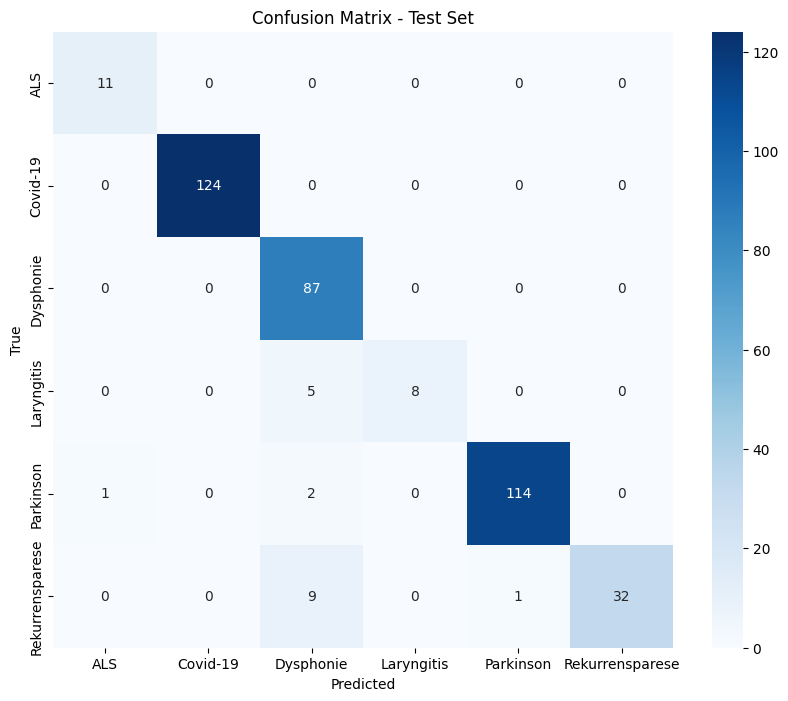

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model_on_test_set(model, test_loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            predictions = torch.argmax(outputs, axis=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix - Test Set")
    plt.show()

    return precision, recall, f1, mcc

final_model.load_state_dict(torch.load('/content/MA/best_resnet50_FP_model.pth'))
final_model.to(device)

precision, recall, f1, mcc = evaluate_model_on_test_set(final_model, test_loader)

In [ ]:
### two stage architecture test

Using device: cuda


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 216MB/s]
<ipython-input-2-c5a47238f324>:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded

Total samples: 2702
Samples classified as HC: 1893
Precision: 0.9600
Recall: 0.9589
F1 Score: 0.9583
MCC: 0.9174


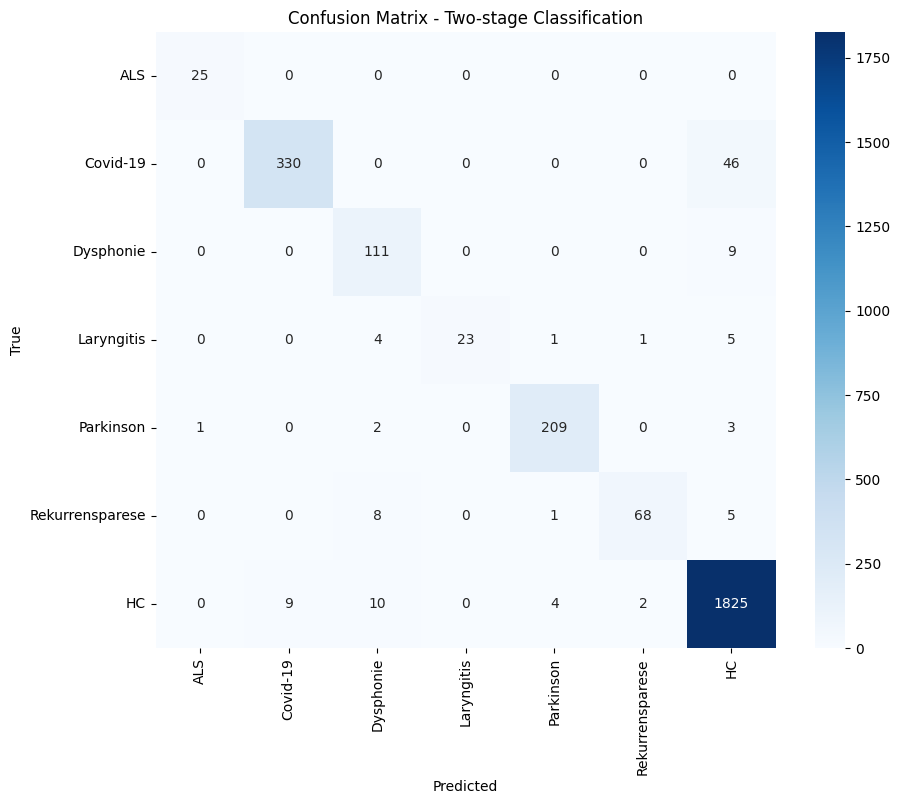

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import random
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import matthews_corrcoef, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import models
from torchvision.models import ResNet50_Weights

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Class Mapping
group_classes = {"MC": 0, "MP": 1, "FC": 2, "FP": 3}
disease_classes = {
    "ALS": 0,
    "Covid-19": 1,
    "Dysphonie": 2,
    "Laryngitis": 3,
    "Parkinson": 4,
    "Rekurrensparese": 5,
    "HC": 6
}

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

def load_model(model_path, num_classes):
    model = ResNet50Classifier(num_classes=num_classes).to(device)
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    return model

def get_test_loader(test_files, test_labels, batch_size=32):
    test_dataset = MelDataset(test_files, test_labels)
    return DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Load Group Classifier
group_model = load_model("/content/MA/final_group_classifier.pth", num_classes=4)

# Load MP and FP Classifier
mp_model = load_model("/content/MA/best_resnet50_MP_model.pth", num_classes=6)
fp_model = load_model("/content/MA/best_resnet50_FP_model.pth", num_classes=6)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        pathology = row['Pathology']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and pathology in disease_classes:
            files.append(full_path)
            labels.append(disease_classes[pathology])
        else:
            print(f"Warning: File {full_path} does not exist or invalid pathology.")
    return files, labels

test_set_path = os.path.join("/content/MA", "test_set.xlsx")
test_df = pd.read_excel(test_set_path)
test_files, test_labels = get_file_paths_and_labels(test_df, "/content/MA")

test_loader = get_test_loader(test_files, test_labels)

y_true, y_pred = [], []

total_samples, mc_fc_count = 0, 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.numpy()
        if len(inputs.shape) == 5:
            inputs = inputs.squeeze(2)
        group_outputs = group_model(inputs)
        group_preds = torch.argmax(group_outputs, axis=1).cpu().numpy()

        for i, group_pred in enumerate(group_preds):
            if group_pred in [group_classes["MC"], group_classes["FC"]]:
                y_true.append(labels[i])
                y_pred.append(disease_classes["HC"])
                mc_fc_count += 1
            elif group_pred == group_classes["MP"]:
                mp_output = mp_model(inputs[i].unsqueeze(0))
                mp_pred = torch.argmax(mp_output, axis=1).cpu().item()
                y_true.append(labels[i])
                y_pred.append(mp_pred)
            elif group_pred == group_classes["FP"]:
                fp_output = fp_model(inputs[i].unsqueeze(0))
                fp_pred = torch.argmax(fp_output, axis=1).cpu().item()
                y_true.append(labels[i])
                y_pred.append(fp_pred)

print(f"Total samples: {len(test_labels)}")
print(f"Samples classified as HC: {mc_fc_count}")

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
mcc = matthews_corrcoef(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=disease_classes.keys(),
            yticklabels=disease_classes.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Two-stage Classification")
plt.show()
